In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Retail demand forecasting is a critical challenge for large-scale businesses such as Walmart, one of the leading retail chains in the United States. With sales data spanning 45 stores across different regions, the core problem lies in accurately predicting weekly sales in the presence of complex influencing factors such as promotional markdowns, economic indicators (CPI, Unemployment Index), and major holiday events including the Super Bowl, Labour Day, Thanksgiving, and Christmas. Holiday weeks are particularly significant, as they are weighted five times higher in evaluation than non-holiday weeks, making their accurate prediction especially important. The absence of complete historical data during markdown periods further compounds the forecasting difficulty. To address this, three time-series forecasting models, such as Prophet, LightGBM, and SARIMAX were developed and systematically optimized using the Taguchi method, a structured parameter tuning approach based on orthogonal arrays, with the goal of identifying the most accurate and robust model for Walmart's weekly sales prediction

In [5]:
# ============================================================
#  CELL 1 — INSTALL
# ============================================================
!pip install prophet lightgbm statsmodels shap scikit-learn -q

# ============================================================
#  CELL 2 — IMPORTS & CONFIG
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import itertools  # built-in, tidak perlu pip install

# ── Machine Learning ──────────────────────────────────────
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# ── Models ───────────────────────────────────────────────
from prophet import Prophet
import lightgbm as lgb
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ── SHAP ─────────────────────────────────────────────────
import shap

# ── Style ─────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = {'Prophet': '#4f8ef7', 'LightGBM': '#7c5cfc', 'SARIMAX': '#22c97a'}
STORE_ID = 1

# ============================================================
#  CELL 3 — MOUNT DRIVE & LOAD DATA
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

df_raw = pd.read_csv('/content/drive/MyDrive/Data/Walmart.csv')
df_raw['Date'] = pd.to_datetime(df_raw['Date'], dayfirst=True)
df_raw = df_raw.sort_values(['Store', 'Date']).reset_index(drop=True)

# Store 1 untuk Prophet & SARIMAX
df1 = df_raw[df_raw['Store'] == STORE_ID].copy().reset_index(drop=True)

print(f"Datasets   : {df_raw.shape[0]} lines")
print(f"Store     : {df_raw['Store'].nunique()}")
print(f"Periods   : {df_raw['Date'].min().date()} – {df_raw['Date'].max().date()}")
print(f"Store {STORE_ID}   : {df1.shape[0]} weeks")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Datasets   : 6435 lines
Store     : 45
Periods   : 2010-02-05 – 2012-10-26
Store 1   : 143 weeks


## SECTION 1 – DESCRIPTIVE STATISTICS


  SECTION 1 — DESCRIPTIVE STATISTICS

── Descriptive Statistics ─────────────────────────────
               count         mean         std         min         25%         50%          75%          max   cv_%  skewness  kurtosis
Weekly_Sales  6435.0  1046964.878  564366.622  209986.250  553350.105  960746.040  1420158.660  3818686.450  53.91     0.668     0.053
Temperature   6435.0       60.664      18.445      -2.060      47.460      62.670       74.940      100.140  30.41    -0.337    -0.613
Fuel_Price    6435.0        3.359       0.459       2.472       2.933       3.445        3.735        4.468  13.67    -0.096    -1.177
CPI           6435.0      171.578      39.357     126.064     131.735     182.617      212.743      227.233  22.94     0.063    -1.840
Unemployment  6435.0        7.999       1.876       3.879       6.891       7.874        8.622       14.313  23.45     1.188     2.640

── Weekly Sales: Holiday vs Non-Holiday ───────────────
                   mean      median   

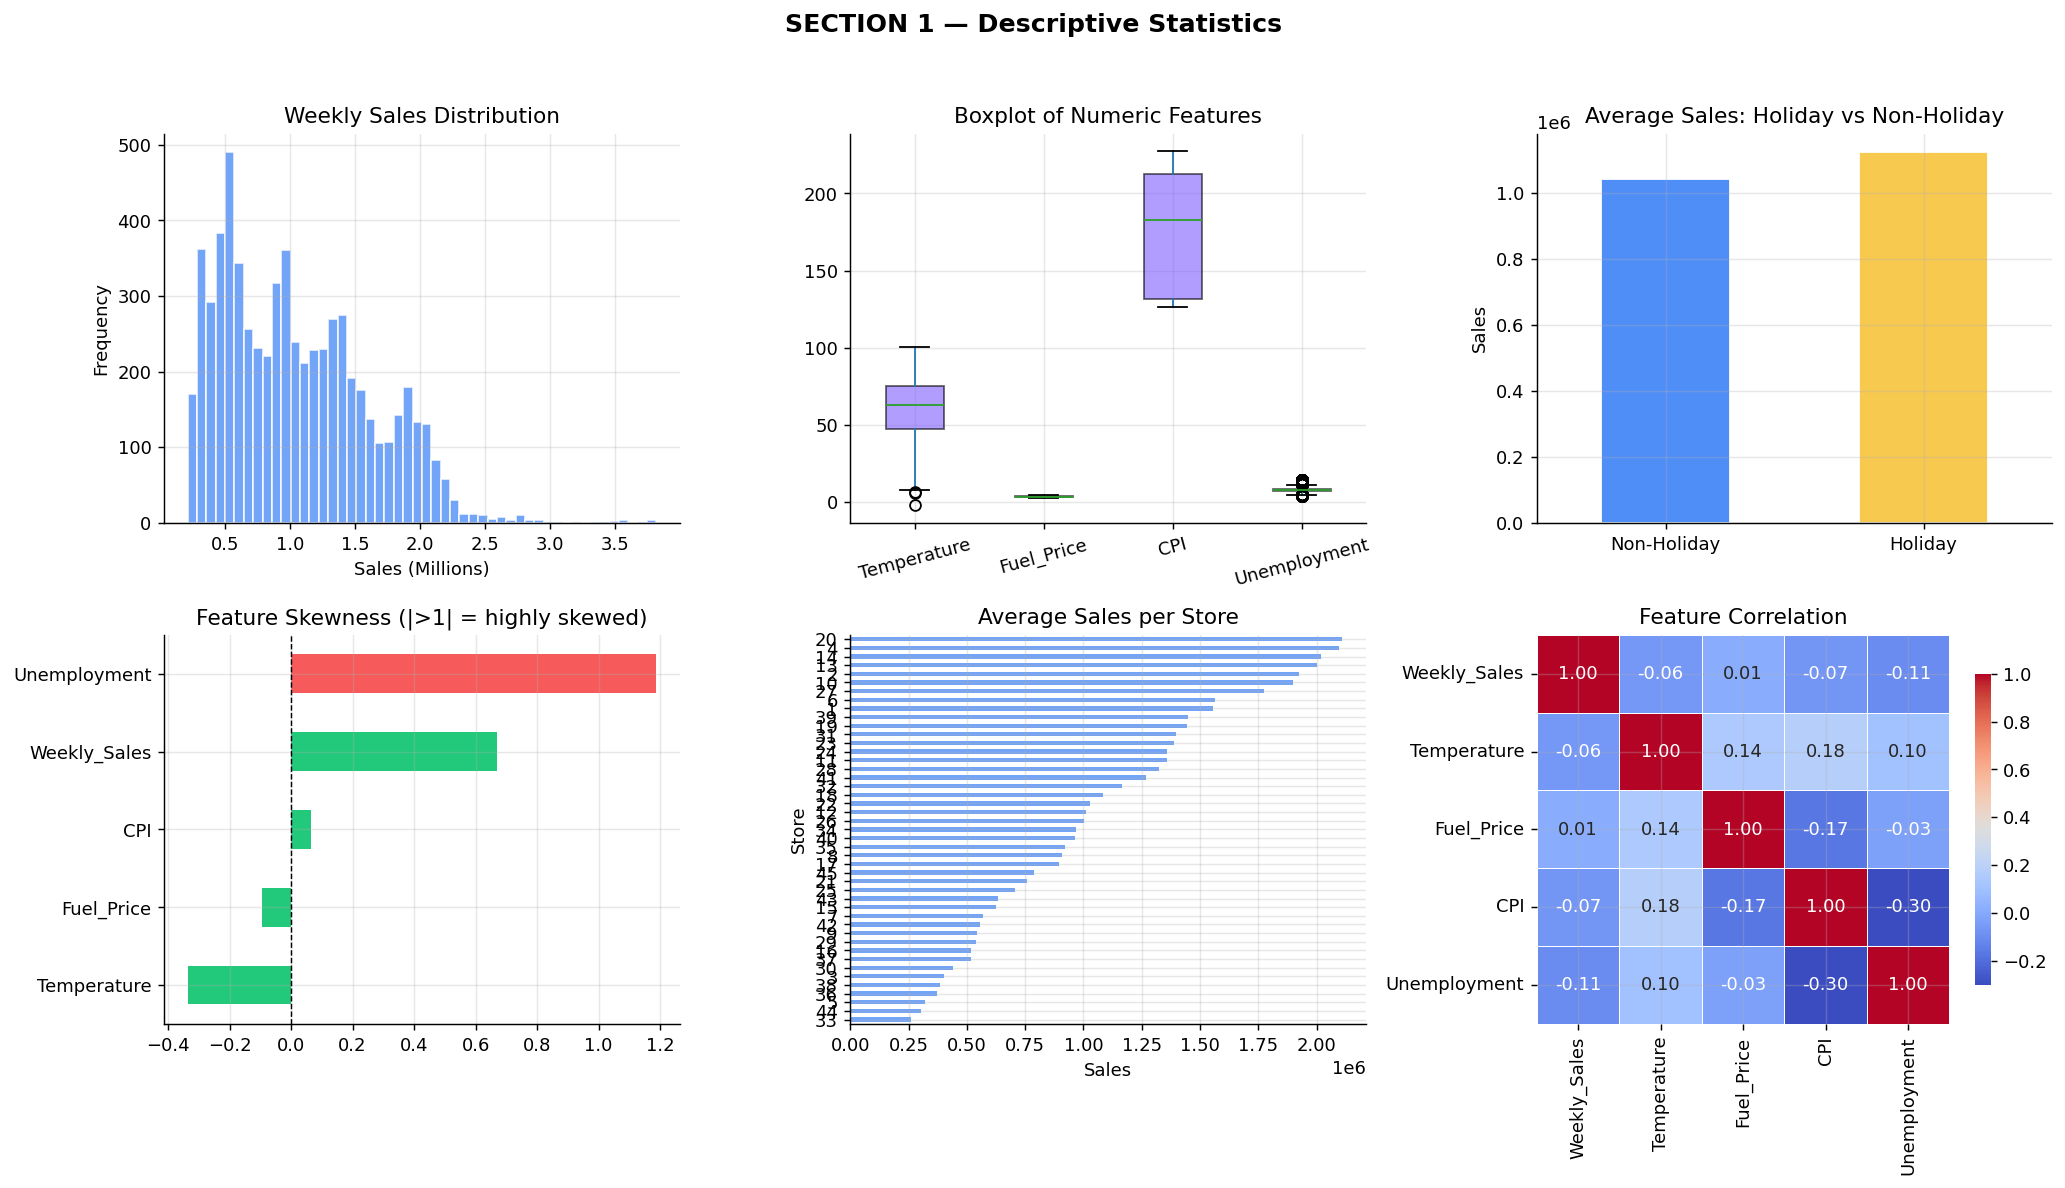

→ Chart saved: sec1_descriptive.png


In [7]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SECTION 1 – DESCRIPTIVE STATISTICS                     ║
# ╚══════════════════════════════════════════════════════════╝
print("\n" + "="*60)
print("  SECTION 1 — DESCRIPTIVE STATISTICS")
print("="*60)

num_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

desc = df_raw[num_cols].describe().T
desc['cv_%'] = (desc['std'] / desc['mean'] * 100).round(2)
desc['skewness'] = df_raw[num_cols].skew().values
desc['kurtosis'] = df_raw[num_cols].kurt().values
print("\n── Descriptive Statistics ─────────────────────────────")
print(desc.round(3).to_string())

# Holiday vs Non-Holiday
print("\n── Weekly Sales: Holiday vs Non-Holiday ───────────────")
hol = df_raw.groupby('Holiday_Flag')['Weekly_Sales'].agg(['mean', 'median', 'std'])
hol.index = ['Non-Holiday', 'Holiday']
print(hol.round(2))

# Per-store summary
store_summary = df_raw.groupby('Store')['Weekly_Sales'].agg(
    Mean='mean', Std='std', Min='min', Max='max'
).round(0)
print("\n── Top 5 Stores (Highest Average Sales) ───────────────")
print(store_summary.sort_values('Mean', ascending=False).head(5))

# ── Visualization ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('SECTION 1 — Descriptive Statistics', fontsize=14, fontweight='bold', y=1.01)

# 1a. Weekly Sales Distribution
ax = axes[0, 0]
ax.hist(df_raw['Weekly_Sales'] / 1e6, bins=50, color='#4f8ef7', alpha=0.8,
        edgecolor='white', lw=0.3)
ax.set_title('Weekly Sales Distribution')
ax.set_xlabel('Sales (Millions)')
ax.set_ylabel('Frequency')

# 1b. Boxplot of numeric features
ax = axes[0, 1]
df_raw[num_cols[1:]].boxplot(ax=ax, patch_artist=True,
    boxprops=dict(facecolor='#7c5cfc', alpha=0.6))
ax.set_title('Boxplot of Numeric Features')
ax.tick_params(axis='x', rotation=15)

# 1c. Holiday vs Non-Holiday bar  ← FIXED: 'mean' lowercase
ax = axes[0, 2]
hol['mean'].plot(kind='bar', ax=ax, color=['#4f8ef7', '#f7c94f'], edgecolor='white')
ax.set_title('Average Sales: Holiday vs Non-Holiday')
ax.set_ylabel('Sales')
ax.set_xticklabels(['Non-Holiday', 'Holiday'], rotation=0)

# 1d. Skewness bar
ax = axes[1, 0]
skew_vals = df_raw[num_cols].skew().sort_values()
colors = ['#f75a5a' if abs(v) > 1 else '#22c97a' for v in skew_vals]
skew_vals.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_title('Feature Skewness (|>1| = highly skewed)')

# 1e. Store mean sales
ax = axes[1, 1]
store_summary['Mean'].sort_values().plot(kind='barh', ax=ax, color='#4f8ef7', alpha=0.8)
ax.set_title('Average Sales per Store')
ax.set_xlabel('Sales')

# 1f. Correlation heatmap
ax = axes[1, 2]
corr = df_raw[num_cols].corr()
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation')

plt.tight_layout()
plt.savefig('sec1_descriptive.png', bbox_inches='tight')
plt.show()
print("→ Chart saved: sec1_descriptive.png")

## SECTION 2 – EDA


  SECTION 2 — EXPLORATORY DATA ANALYSIS

ADF p-value Store 1: 0.0000 → Stationary


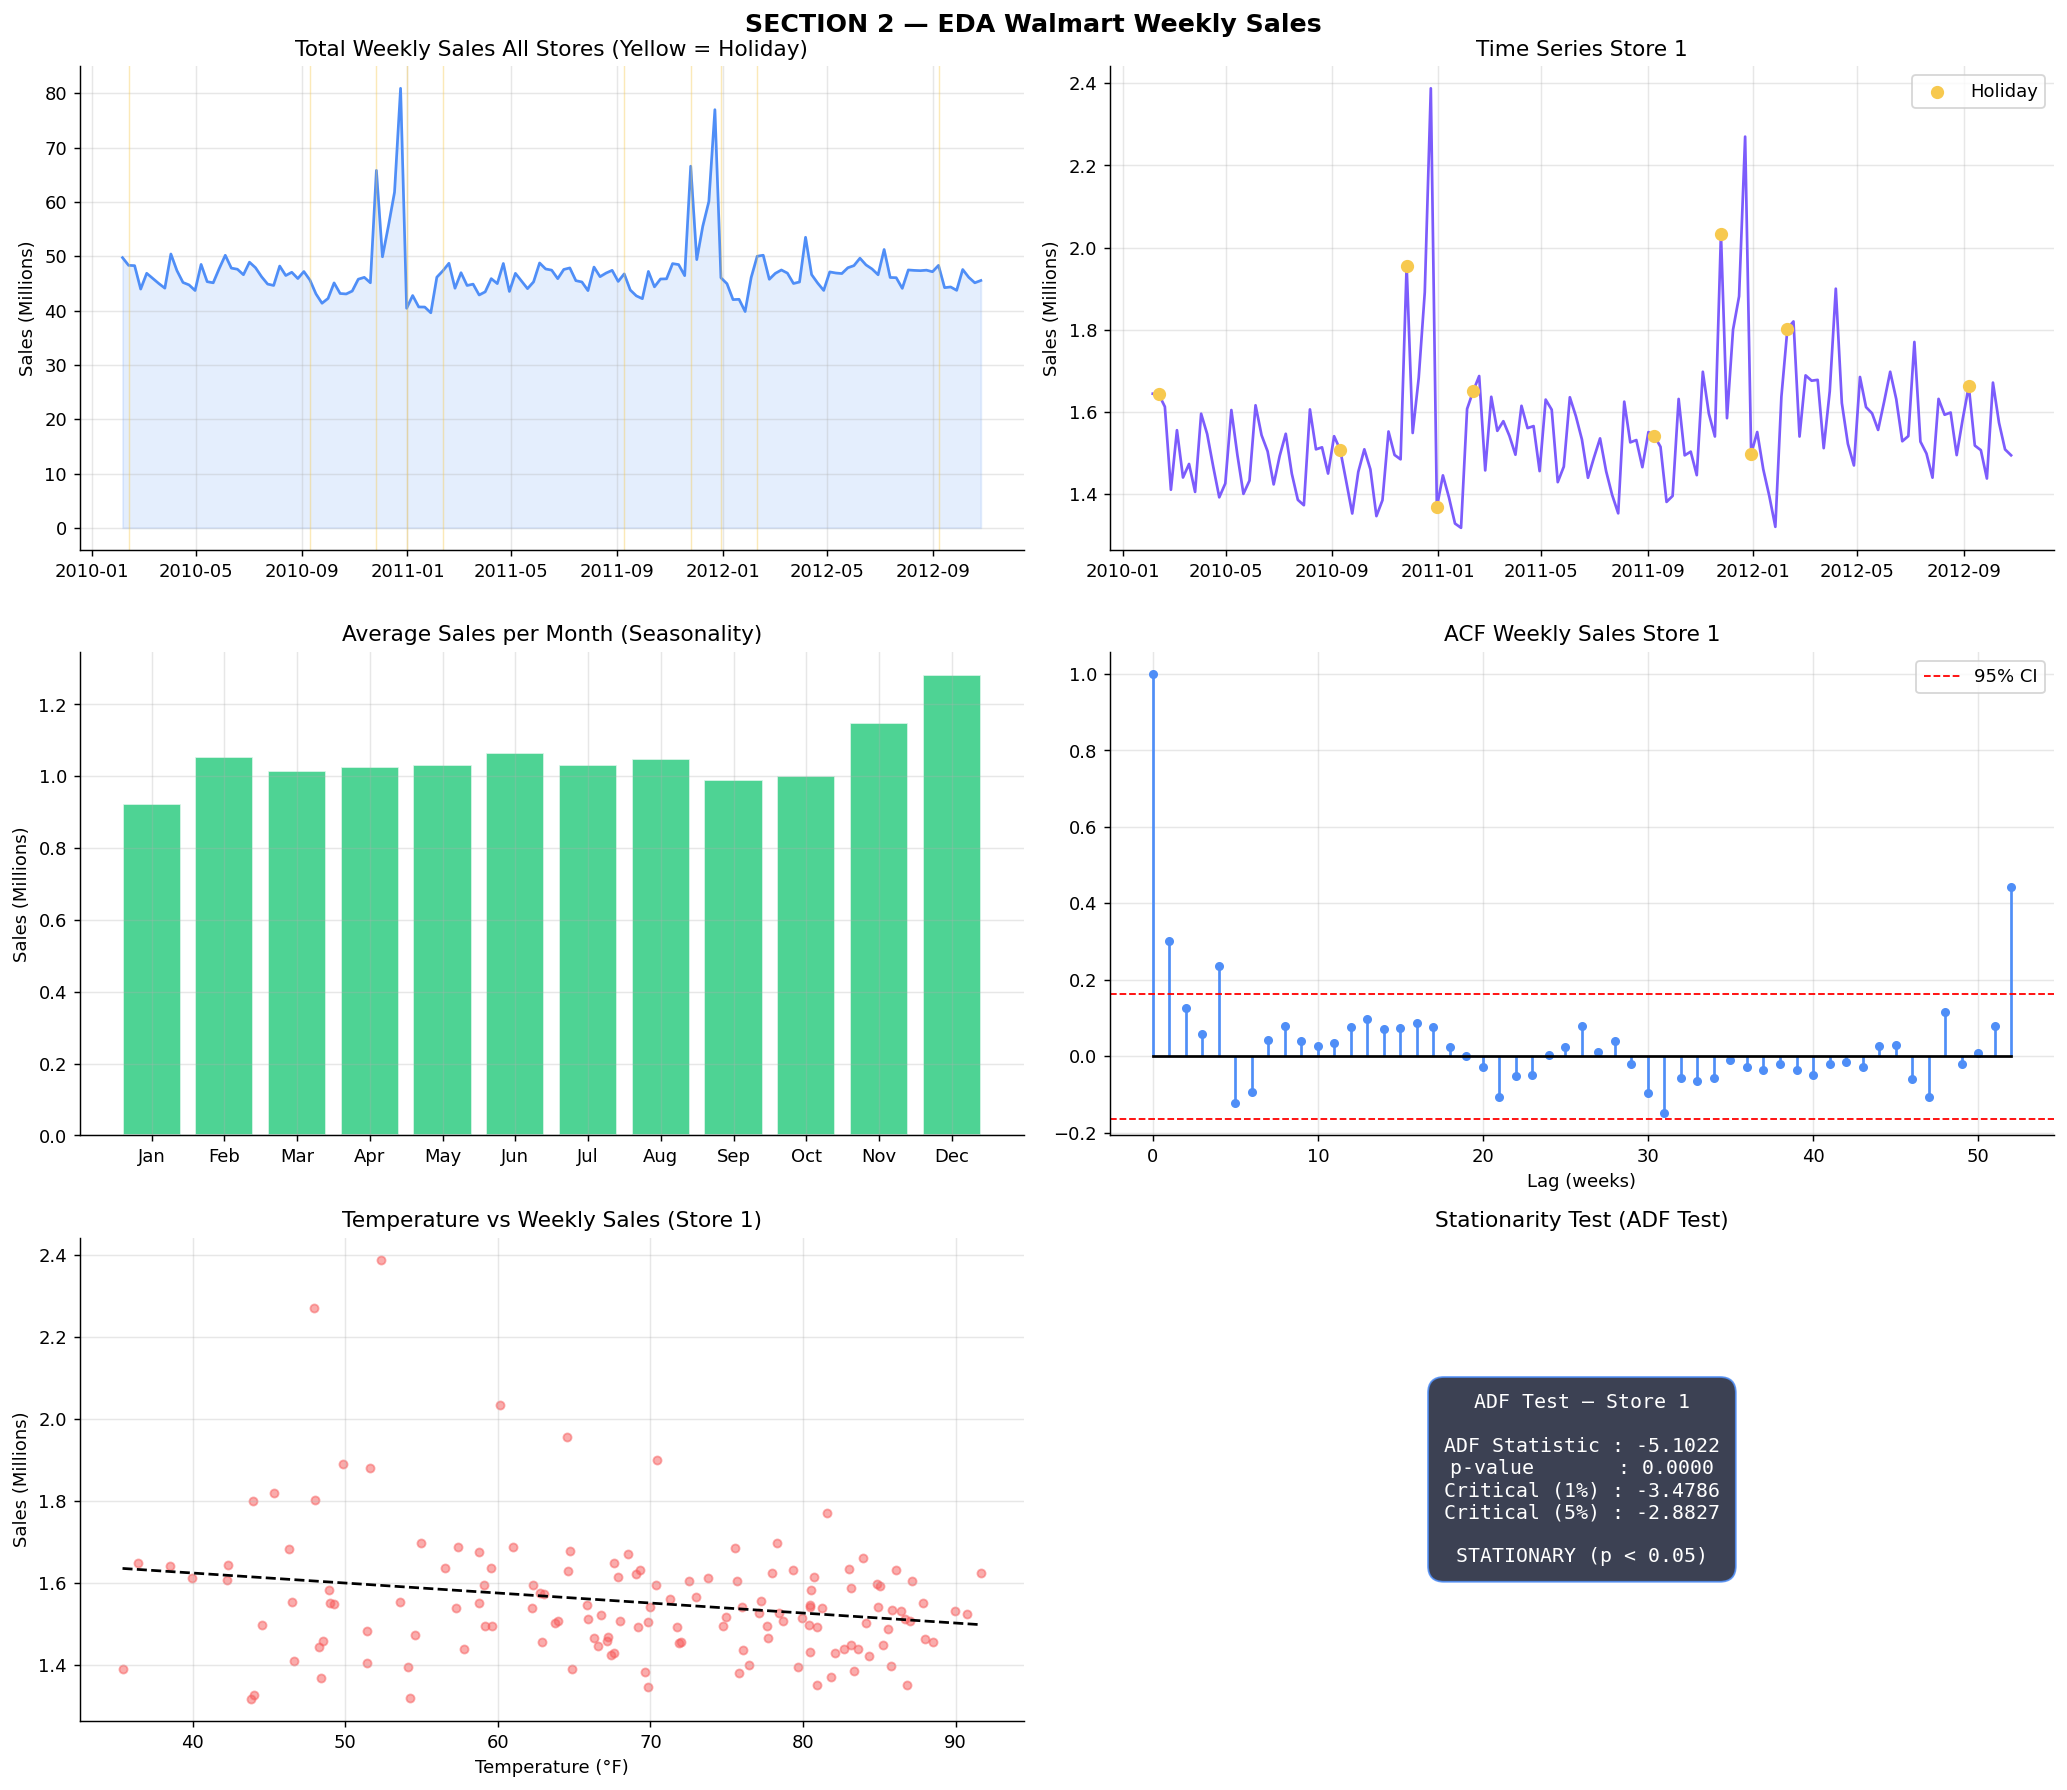

→ Chart saved: sec2_eda.png


In [9]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SECTION 2 – EDA                                        ║
# ╚══════════════════════════════════════════════════════════╝
print("\n" + "="*60)
print("  SECTION 2 — EXPLORATORY DATA ANALYSIS")
print("="*60)

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('SECTION 2 — EDA Walmart Weekly Sales', fontsize=14, fontweight='bold')

# 2a. Time series total sales
ax = axes[0, 0]
total_weekly = df_raw.groupby('Date')['Weekly_Sales'].sum() / 1e6
ax.plot(total_weekly.index, total_weekly.values, color='#4f8ef7', lw=1.5)
ax.fill_between(total_weekly.index, total_weekly.values, alpha=0.15, color='#4f8ef7')
holidays = df_raw[df_raw['Holiday_Flag'] == 1]['Date'].unique()
for hd in holidays:
    ax.axvline(hd, color='#f7c94f', alpha=0.4, lw=0.8)
ax.set_title('Total Weekly Sales All Stores (Yellow = Holiday)')
ax.set_ylabel('Sales (Millions)')

# 2b. Store 1 time series
ax = axes[0, 1]
ax.plot(df1['Date'], df1['Weekly_Sales'] / 1e6, color='#7c5cfc', lw=1.5)
h_dates = df1[df1['Holiday_Flag'] == 1]['Date']
h_vals  = df1[df1['Holiday_Flag'] == 1]['Weekly_Sales'] / 1e6
ax.scatter(h_dates, h_vals, color='#f7c94f', zorder=5, s=40, label='Holiday')
ax.set_title(f'Time Series Store {STORE_ID}')
ax.set_ylabel('Sales (Millions)')
ax.legend()

# 2c. Monthly seasonality
ax = axes[1, 0]
df_raw['Month'] = df_raw['Date'].dt.month
monthly = df_raw.groupby('Month')['Weekly_Sales'].mean()
ax.bar(monthly.index, monthly.values / 1e6, color='#22c97a', alpha=0.8, edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Average Sales per Month (Seasonality)')
ax.set_ylabel('Sales (Millions)')

# 2d. ACF Store 1 ← FIXED: use plain format strings, apply color via set_color()
ax = axes[1, 1]
acf_vals = acf(df1['Weekly_Sales'], nlags=52)
markerline, stemlines, baseline = ax.stem(
    range(len(acf_vals)), acf_vals,
    linefmt='-',       # plain format, no hex
    markerfmt='o',
    basefmt='k-'
)
stemlines.set_color('#4f8ef7')   # apply hex color after
markerline.set_color('#4f8ef7')
markerline.set_markersize(4)
ax.axhline( 1.96 / np.sqrt(len(df1)), color='red', ls='--', lw=1, label='95% CI')
ax.axhline(-1.96 / np.sqrt(len(df1)), color='red', ls='--', lw=1)
ax.set_title(f'ACF Weekly Sales Store {STORE_ID}')
ax.set_xlabel('Lag (weeks)')
ax.legend()

# 2e. Temperature vs Sales scatter
ax = axes[2, 0]
ax.scatter(df1['Temperature'], df1['Weekly_Sales'] / 1e6, alpha=0.5, color='#f75a5a', s=20)
z = np.polyfit(df1['Temperature'], df1['Weekly_Sales'] / 1e6, 1)
p = np.poly1d(z)
x_line = np.linspace(df1['Temperature'].min(), df1['Temperature'].max(), 100)
ax.plot(x_line, p(x_line), color='black', lw=1.5, ls='--')
ax.set_title(f'Temperature vs Weekly Sales (Store {STORE_ID})')
ax.set_xlabel('Temperature (°F)')
ax.set_ylabel('Sales (Millions)')

# 2f. ADF Test result
ax = axes[2, 1]
adf_result = adfuller(df1['Weekly_Sales'])
adf_text = (
    f"ADF Test — Store {STORE_ID}\n\n"
    f"ADF Statistic : {adf_result[0]:.4f}\n"
    f"p-value       : {adf_result[1]:.4f}\n"
    f"Critical (1%) : {adf_result[4]['1%']:.4f}\n"
    f"Critical (5%) : {adf_result[4]['5%']:.4f}\n\n"
    f"{'STATIONARY (p < 0.05)' if adf_result[1] < 0.05 else 'NON-STATIONARY (p >= 0.05)'}"
)
ax.text(0.5, 0.5, adf_text, transform=ax.transAxes,
        ha='center', va='center', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#1a1f35', edgecolor='#4f8ef7', alpha=0.85),
        color='white', fontfamily='monospace')
ax.axis('off')
ax.set_title('Stationarity Test (ADF Test)')
print(f"\nADF p-value Store {STORE_ID}: {adf_result[1]:.4f} → "
      f"{'Stationary' if adf_result[1] < 0.05 else 'Non-Stationary'}")

plt.tight_layout()
plt.savefig('sec2_eda.png', bbox_inches='tight')
plt.show()
print("→ Chart saved: sec2_eda.png")

## SECTION 3 – SPLIT DATA & CROSS VALIDATION


  SECTION 3 — SPLIT DATA TRAINING / TESTING
Store 1 | Total: 143 | Train: 114 | Test: 29
  Train: 2010-02-05 → 2012-04-06
  Test : 2012-04-13 → 2012-10-26

LightGBM (Global) | Train: 2745 | Test: 1350

Time Series Cross Validation — 5 Fold (Store 1):
  Fold 1: Train [2010-02-05 → 2010-08-13] | Val [2010-08-20 → 2011-01-21]
  Fold 2: Train [2010-02-05 → 2011-01-21] | Val [2011-01-28 → 2011-07-01]
  Fold 3: Train [2010-02-05 → 2011-07-01] | Val [2011-07-08 → 2011-12-09]
  Fold 4: Train [2010-02-05 → 2011-12-09] | Val [2011-12-16 → 2012-05-18]
  Fold 5: Train [2010-02-05 → 2012-05-18] | Val [2012-05-25 → 2012-10-26]


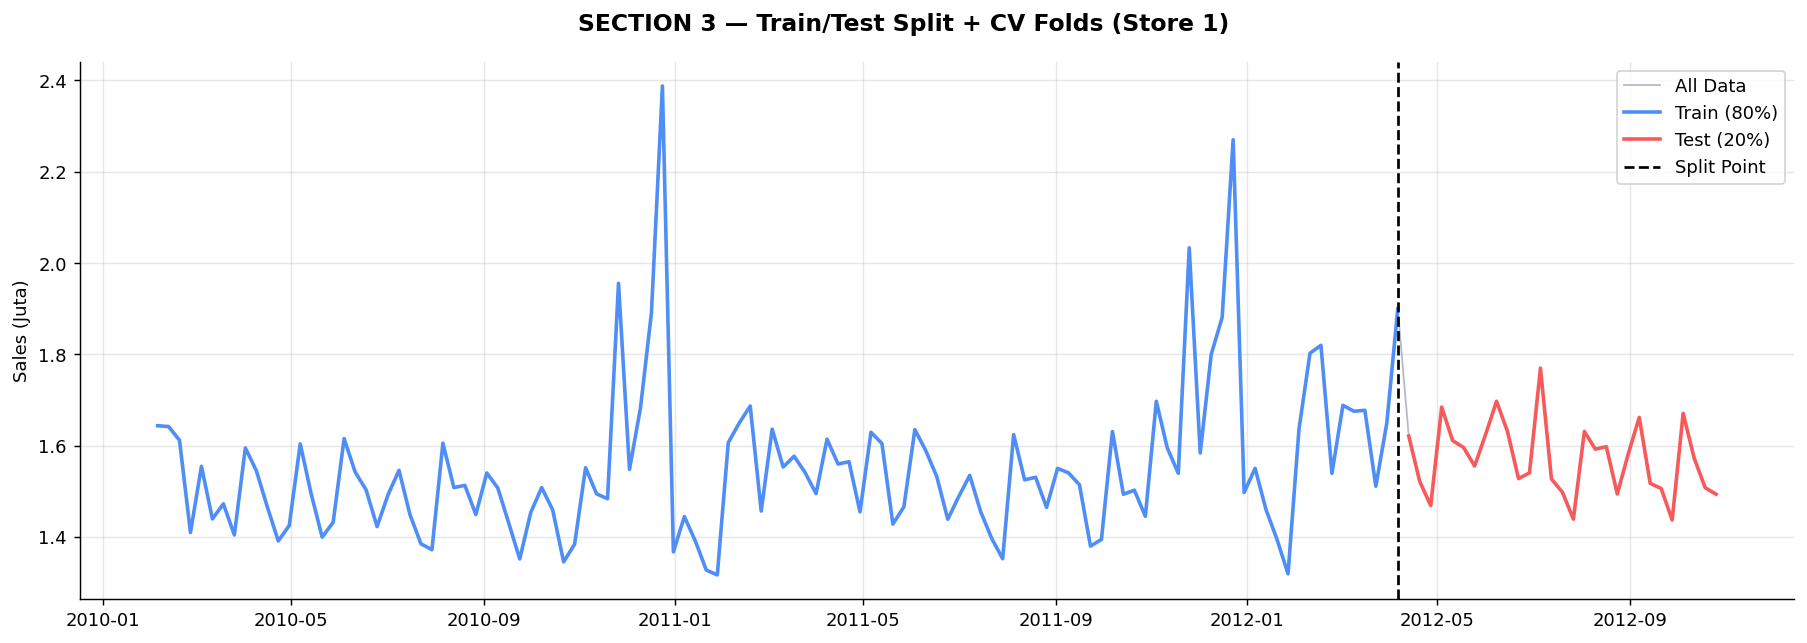

→ Chart saved: sec3_split.png


In [14]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SECTION 3 – SPLIT DATA & CROSS VALIDATION              ║
# ╚══════════════════════════════════════════════════════════╝
print("\n" + "="*60)
print("  SECTION 3 — SPLIT DATA TRAINING / TESTING")
print("="*60)

# ── Split ratio 80:20 (time-based) ──
n = len(df1)
split_idx = int(n * 0.8)
train_df1 = df1.iloc[:split_idx].copy()
test_df1  = df1.iloc[split_idx:].copy()

print(f"Store {STORE_ID} | Total: {n} | Train: {len(train_df1)} | Test: {len(test_df1)}")
print(f"  Train: {train_df1['Date'].min().date()} → {train_df1['Date'].max().date()}")
print(f"  Test : {test_df1['Date'].min().date()} → {test_df1['Date'].max().date()}")

# ── LightGBM: lag features ──────────────────────────────
def make_lag_features(df_all):
    df_all = df_all.copy().sort_values(['Store', 'Date'])
    for lag in [1, 2, 3, 4, 8, 12, 52]:
        df_all[f'lag_{lag}'] = df_all.groupby('Store')['Weekly_Sales'].shift(lag)
    for w in [4, 8, 12]:
        df_all[f'roll_mean_{w}'] = df_all.groupby('Store')['Weekly_Sales'].transform(
            lambda x: x.shift(1).rolling(w).mean())
        df_all[f'roll_std_{w}'] = df_all.groupby('Store')['Weekly_Sales'].transform(
            lambda x: x.shift(1).rolling(w).std())
    df_all['week_of_year'] = df_all['Date'].dt.isocalendar().week.astype(int)
    df_all['month']        = df_all['Date'].dt.month
    df_all['year']         = df_all['Date'].dt.year
    return df_all

df_lgb_full = make_lag_features(df_raw)
df_lgb_full = df_lgb_full.dropna().reset_index(drop=True)

FEAT_COLS = ['Store','week_of_year','month','year','Holiday_Flag',
             'Temperature','Fuel_Price','CPI','Unemployment',
             'lag_1','lag_2','lag_3','lag_4','lag_8','lag_12','lag_52',
             'roll_mean_4','roll_mean_8','roll_mean_12',
             'roll_std_4','roll_std_8','roll_std_12']

# Time-based split LightGBM (global)
split_date = pd.Timestamp('2012-04-01')
train_lgb = df_lgb_full[df_lgb_full['Date'] < split_date]
test_lgb  = df_lgb_full[df_lgb_full['Date'] >= split_date]
X_train_lgb = train_lgb[FEAT_COLS]; y_train_lgb = train_lgb['Weekly_Sales']
X_test_lgb  = test_lgb[FEAT_COLS];  y_test_lgb  = test_lgb['Weekly_Sales']
print(f"\nLightGBM (Global) | Train: {len(train_lgb)} | Test: {len(test_lgb)}")

# ── Time Series Cross Validation ──────────────────────────
tscv = TimeSeriesSplit(n_splits=5)
print(f"\nTime Series Cross Validation — 5 Fold (Store {STORE_ID}):")
X_cv = df1['Weekly_Sales'].values
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_cv), 1):
    print(f"  Fold {fold}: Train [{df1['Date'].iloc[tr_idx[0]].date()} → "
          f"{df1['Date'].iloc[tr_idx[-1]].date()}] | "
          f"Val [{df1['Date'].iloc[val_idx[0]].date()} → "
          f"{df1['Date'].iloc[val_idx[-1]].date()}]")

# Visualisasi split
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('SECTION 3 — Train/Test Split + CV Folds (Store 1)', fontsize=13, fontweight='bold')
ax.plot(df1['Date'], df1['Weekly_Sales']/1e6, color='#6b7499', lw=1, alpha=0.5, label='All Data')
ax.plot(train_df1['Date'], train_df1['Weekly_Sales']/1e6, color='#4f8ef7', lw=2, label='Train (80%)')
ax.plot(test_df1['Date'], test_df1['Weekly_Sales']/1e6, color='#f75a5a', lw=2, label='Test (20%)')
ax.axvline(train_df1['Date'].max(), color='black', ls='--', lw=1.5, label='Split Point')
ax.set_ylabel('Sales (Juta)')
ax.legend()
plt.tight_layout()
plt.savefig('sec3_split.png', bbox_inches='tight')
plt.show()
print("→ Chart saved: sec3_split.png")

## SECTION 4 – TRAINING MODEL


  SECTION 4 — INITIAL MODELING (BASELINE TRAINING)

[Prophet] Training baseline...
  ✓ Prophet baseline complete

[LightGBM] Training baseline...
  ✓ LightGBM baseline complete

[SARIMAX] Training baseline (p=1,d=0,q=1)(P=1,D=1,Q=1,s=52)...
  ✓ SARIMAX baseline complete

  SARIMAX AIC: 217.87

── Baseline Metrics ───────────────────────────────────
  Prophet      → MAE:       92,566 | RMSE:      108,714 | MAPE: 6.02%
  LightGBM     → MAE:       44,364 | RMSE:       70,408 | MAPE: 4.28%
  SARIMAX      → MAE:      115,195 | RMSE:      125,410 | MAPE: 7.40%


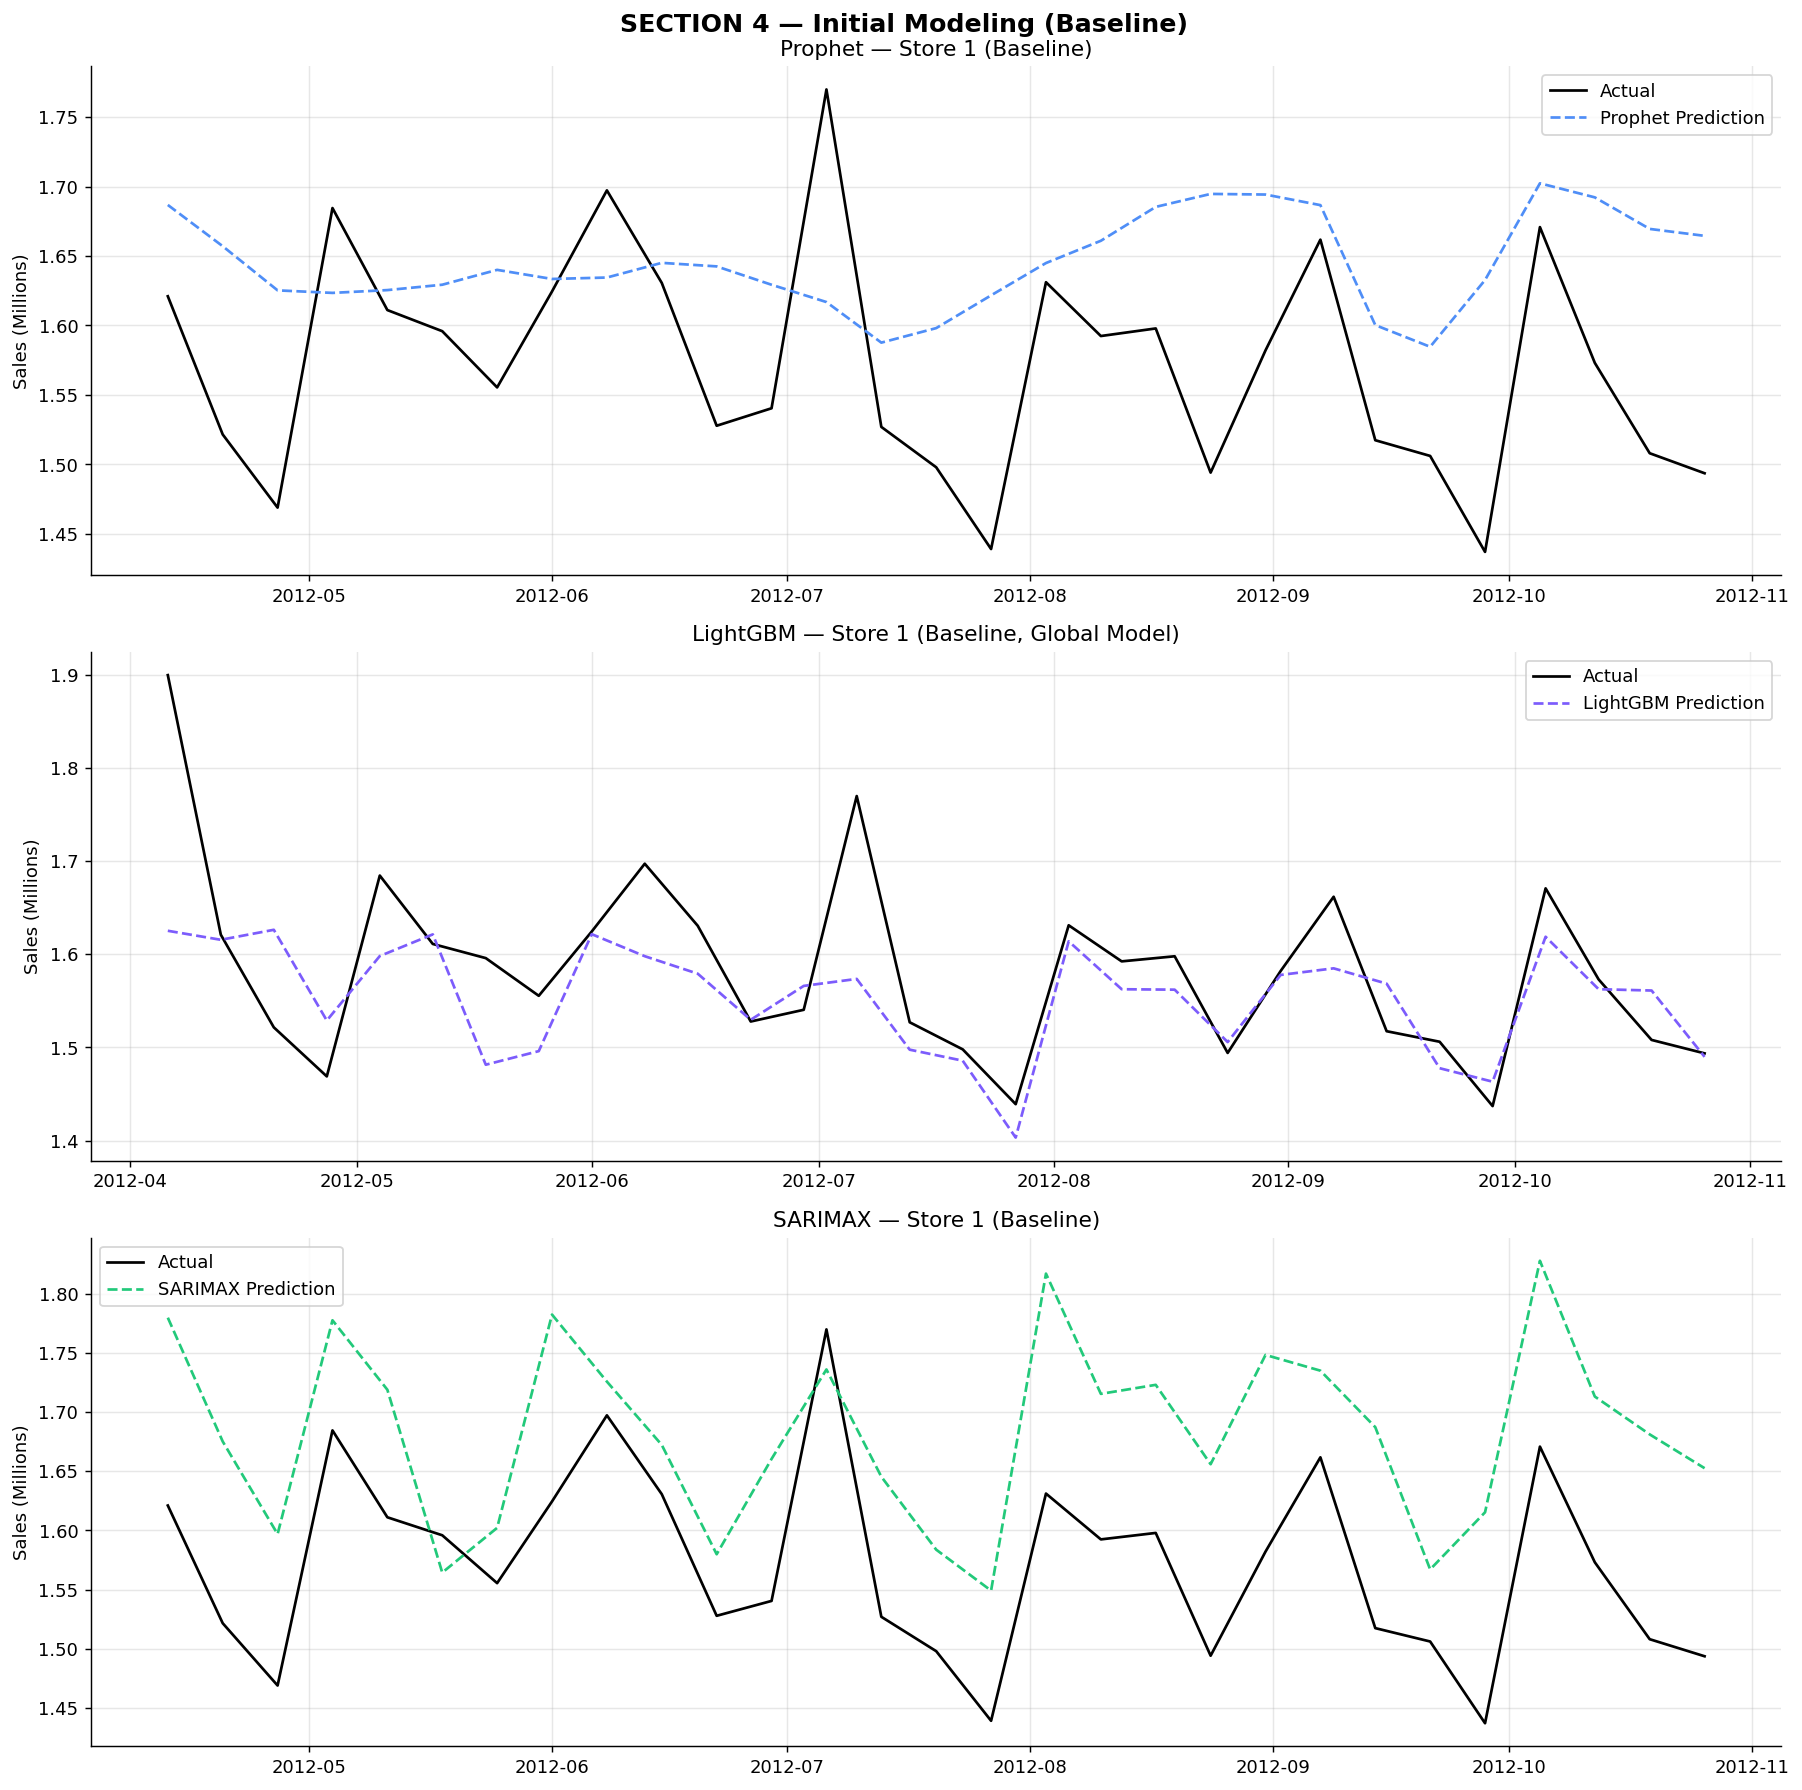

→ Chart saved: sec4_baseline.png


In [15]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SECTION 4 – TRAINING                                   ║
# ╚══════════════════════════════════════════════════════════╝
print("\n" + "="*60)
print("  SECTION 4 — INITIAL MODELING (BASELINE TRAINING)")
print("="*60)

# ──────────────────────────────────────────────────────────
# 4A. PROPHET (baseline)
# ──────────────────────────────────────────────────────────
print("\n[Prophet] Training baseline...")

prophet_train = train_df1.rename(columns={'Date':'ds','Weekly_Sales':'y'})
prophet_test  = test_df1.rename(columns={'Date':'ds','Weekly_Sales':'y'})

regressors = ['Temperature','Fuel_Price','CPI','Unemployment','Holiday_Flag']

m_prophet_base = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)
for reg in regressors:
    m_prophet_base.add_regressor(reg)

m_prophet_base.fit(prophet_train[['ds','y'] + regressors])

future_base = prophet_test[['ds'] + regressors].copy()
fc_prophet_base = m_prophet_base.predict(future_base)
pred_prophet_base = fc_prophet_base['yhat'].values
true_vals_prophet = prophet_test['y'].values

print("  ✓ Prophet baseline complete")

# ──────────────────────────────────────────────────────────
# 4B. LightGBM (baseline)
# ──────────────────────────────────────────────────────────
print("\n[LightGBM] Training baseline...")

lgb_base_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'n_estimators': 300,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1
}
model_lgb_base = lgb.LGBMRegressor(**lgb_base_params)
model_lgb_base.fit(X_train_lgb, y_train_lgb,
                   eval_set=[(X_test_lgb, y_test_lgb)],
                   callbacks=[lgb.early_stopping(30, verbose=False),
                               lgb.log_evaluation(period=-1)])
pred_lgb_base = model_lgb_base.predict(X_test_lgb)
print("  ✓ LightGBM baseline complete")

# ──────────────────────────────────────────────────────────
# 4C. SARIMAX (baseline)
# ──────────────────────────────────────────────────────────
print("\n[SARIMAX] Training baseline (p=1,d=0,q=1)(P=1,D=1,Q=1,s=52)...")

exog_cols = ['Temperature','Fuel_Price','CPI','Unemployment','Holiday_Flag']
train_exog = train_df1[exog_cols].values
test_exog  = test_df1[exog_cols].values

model_sarimax_base = SARIMAX(
    train_df1['Weekly_Sales'],
    exog=train_exog,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)
result_sarimax_base = model_sarimax_base.fit(disp=False)
pred_sarimax_base = result_sarimax_base.forecast(steps=len(test_df1), exog=test_exog)
print("  ✓ SARIMAX baseline complete")
print(f"\n  SARIMAX AIC: {result_sarimax_base.aic:.2f}")

# ── Helper metrics ─────────────────────────────────────────
def calc_metrics(true, pred, label=''):
    mae  = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = np.mean(np.abs((true - pred) / (true + 1e-8))) * 100
    print(f"  {label:12s} → MAE: {mae:>12,.0f} | RMSE: {rmse:>12,.0f} | MAPE: {mape:.2f}%")
    return mae, rmse, mape

print("\n── Baseline Metrics ───────────────────────────────────")
mae_pb, rmse_pb, mape_pb = calc_metrics(true_vals_prophet, pred_prophet_base, 'Prophet')
mae_lb, rmse_lb, mape_lb = calc_metrics(y_test_lgb.values, pred_lgb_base,     'LightGBM')
mae_sb, rmse_sb, mape_sb = calc_metrics(test_df1['Weekly_Sales'].values, pred_sarimax_base, 'SARIMAX')

# ── Baseline prediction visualization ─────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle('SECTION 4 — Initial Modeling (Baseline)', fontsize=14, fontweight='bold')

for ax, name, true, pred, color in [
    (axes[0], 'Prophet', true_vals_prophet,                pred_prophet_base,        '#4f8ef7'),
    (axes[2], 'SARIMAX', test_df1['Weekly_Sales'].values,  pred_sarimax_base.values, '#22c97a'),
]:
    ax.plot(test_df1['Date'].values, true/1e6, label='Actual',              color='black', lw=1.5)
    ax.plot(test_df1['Date'].values, pred/1e6, label=f'{name} Prediction',  color=color,   lw=1.5, ls='--')
    ax.set_title(f'{name} — Store {STORE_ID} (Baseline)')
    ax.set_ylabel('Sales (Millions)')
    ax.legend()

ax = axes[1]
lgb_s1   = test_lgb[test_lgb['Store'] == STORE_ID].copy()
pred_s1  = model_lgb_base.predict(lgb_s1[FEAT_COLS])
ax.plot(lgb_s1['Date'], lgb_s1['Weekly_Sales']/1e6, label='Actual',               color='black',   lw=1.5)
ax.plot(lgb_s1['Date'], pred_s1/1e6,                label='LightGBM Prediction',   color='#7c5cfc', lw=1.5, ls='--')
ax.set_title(f'LightGBM — Store {STORE_ID} (Baseline, Global Model)')
ax.set_ylabel('Sales (Millions)')
ax.legend()

plt.tight_layout()
plt.savefig('sec4_baseline.png', bbox_inches='tight')
plt.show()
print("→ Chart saved: sec4_baseline.png")

## SECTION 5 – TAGUCHI PARAMETER TUNING


  SECTION 5 — TAGUCHI METHOD PARAMETER TUNING

[Prophet] Taguchi L9 Tuning...
  Total runs: 9 | Validation size: 23 weeks
-------------------------------------------------------
  Run 1/9 | cps=0.01, sps=0.01, mode=additive, cr=0.7 | MAPE: 7.10% | S/N: -17.021 | 0.9s
  Run 2/9 | cps=0.01, sps=1.0, mode=multiplicative, cr=0.8 | MAPE: 9.21% | S/N: -19.285 | 0.3s
  Run 3/9 | cps=0.01, sps=10.0, mode=additive, cr=0.9 | MAPE: 10.31% | S/N: -20.266 | 0.5s
  Run 4/9 | cps=0.1, sps=0.01, mode=multiplicative, cr=0.9 | MAPE: 8.32% | S/N: -18.403 | 0.7s
  Run 5/9 | cps=0.1, sps=1.0, mode=additive, cr=0.7 | MAPE: 10.15% | S/N: -20.128 | 1.5s
  Run 6/9 | cps=0.1, sps=10.0, mode=additive, cr=0.8 | MAPE: 10.15% | S/N: -20.129 | 1.1s
  Run 7/9 | cps=0.5, sps=0.01, mode=additive, cr=0.8 | MAPE: 8.77% | S/N: -18.858 | 3.3s
  Run 8/9 | cps=0.5, sps=1.0, mode=additive, cr=0.9 | MAPE: 10.80% | S/N: -20.666 | 0.9s
  Run 9/9 | cps=0.5, sps=10.0, mode=multiplicative, cr=0.7 | MAPE: 9.76% | S/N: -19.787 | 1.2

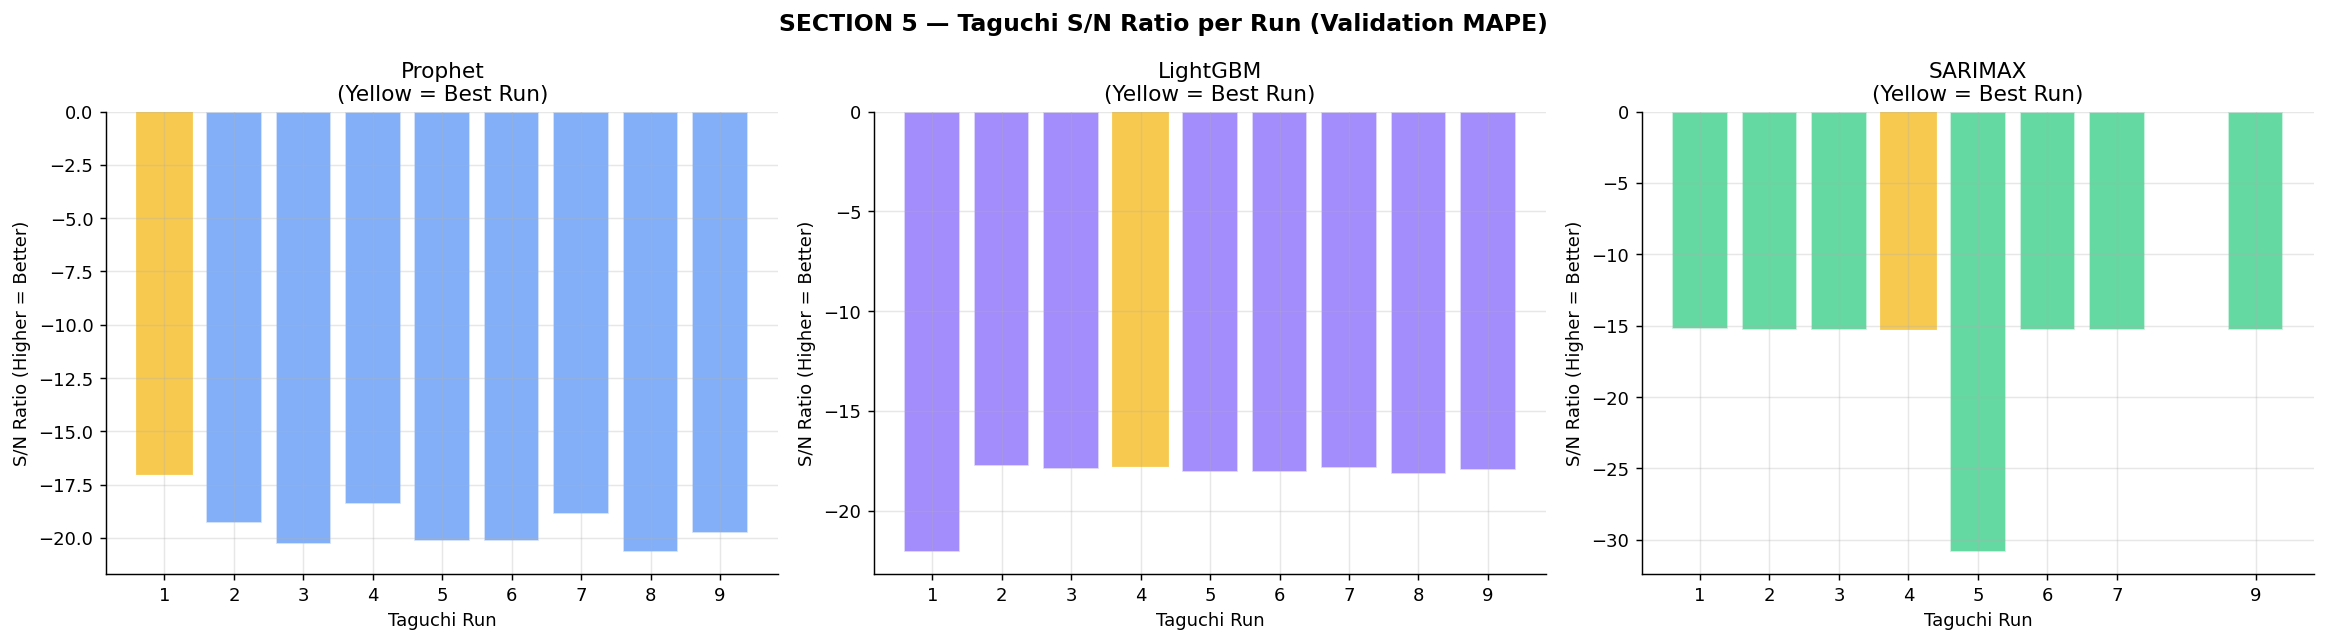

→ Chart saved: sec5_taguchi.png


In [16]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SECTION 5 – TAGUCHI PARAMETER TUNING (VALIDATION)      ║
# ╚══════════════════════════════════════════════════════════╝
print("\n" + "="*60)
print("  SECTION 5 — TAGUCHI METHOD PARAMETER TUNING")
print("="*60)

# ── Taguchi: Orthogonal Array L9 (3^4 → 4 factors, 3 levels) ──
#
# Prophet:    changepoint_prior_scale, seasonality_prior_scale,
#             seasonality_mode, changepoint_range
# LightGBM:   n_estimators, learning_rate, num_leaves, min_child_samples
# SARIMAX:    p, q, P, Q  (d=0, D=1, s=52 fixed)
#
# L9 Orthogonal Array (Taguchi standard)
L9 = [
    [0, 0, 0, 0],
    [0, 1, 1, 1],
    [0, 2, 2, 2],
    [1, 0, 1, 2],
    [1, 1, 2, 0],
    [1, 2, 0, 1],
    [2, 0, 2, 1],
    [2, 1, 0, 2],
    [2, 2, 1, 0],
]

# ── CV split for Taguchi validation ───────────────────────
val_idx_start = int(len(train_df1) * 0.8)
cv_train = train_df1.iloc[:val_idx_start]
cv_val   = train_df1.iloc[val_idx_start:]
cv_train_exog = cv_train[exog_cols].values
cv_val_exog   = cv_val[exog_cols].values

# ────────────────────────────────
# 5A. PROPHET TAGUCHI
# ────────────────────────────────
print("\n[Prophet] Taguchi L9 Tuning...")
print(f"  Total runs: 9 | Validation size: {len(cv_val)} weeks")
print("-" * 55)

p_levels = {
    'changepoint_prior_scale': [0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 1.0, 10.0],
    'seasonality_mode':        ['additive', 'multiplicative', 'additive'],
    'changepoint_range':       [0.7, 0.8, 0.9],
}

taguchi_prophet = []
for run_i, row in enumerate(L9):
    cps  = p_levels['changepoint_prior_scale'][row[0]]
    sps  = p_levels['seasonality_prior_scale'][row[1]]
    mode = ['additive', 'multiplicative', 'additive'][row[2]]
    cr   = p_levels['changepoint_range'][row[3]]

    import time
    t0 = time.time()

    p_tr = cv_train.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
    p_va = cv_val.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})

    m = Prophet(
        changepoint_prior_scale=cps,
        seasonality_prior_scale=sps,
        seasonality_mode=mode,
        changepoint_range=cr,
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )
    for reg in regressors:
        m.add_regressor(reg)
    m.fit(p_tr[['ds', 'y'] + regressors])

    fc = m.predict(p_va[['ds'] + regressors])
    mape_val = np.mean(np.abs((p_va['y'].values - fc['yhat'].values) /
                              (p_va['y'].values + 1e-8))) * 100
    sn = -10 * np.log10(mape_val**2)
    elapsed = time.time() - t0

    taguchi_prophet.append({
        'run': run_i + 1, 'cps': cps, 'sps': sps, 'mode': mode, 'cr': cr,
        'MAPE_val': round(mape_val, 3), 'SN': round(sn, 3)
    })
    print(f"  Run {run_i+1}/9 | cps={cps}, sps={sps}, mode={mode}, cr={cr}"
          f" | MAPE: {mape_val:.2f}% | S/N: {sn:.3f} | {elapsed:.1f}s")

df_tag_prophet = pd.DataFrame(taguchi_prophet)
best_p = df_tag_prophet.loc[df_tag_prophet['MAPE_val'].idxmin()]
print(f"\n  ✓ Best Prophet params: cps={best_p['cps']}, sps={best_p['sps']}, "
      f"mode={best_p['mode']}, cr={best_p['cr']} → MAPE={best_p['MAPE_val']}%")

# ────────────────────────────────
# 5B. LightGBM TAGUCHI
# ────────────────────────────────
print("\n[LightGBM] Taguchi L9 Tuning...")
print(f"  Total runs: 9")
print("-" * 55)

lgb_levels = {
    'n_estimators':      [200, 500, 1000],
    'learning_rate':     [0.01, 0.05, 0.1],
    'num_leaves':        [15, 31, 63],
    'min_child_samples': [5, 20, 50],
}

cv_split_date = pd.Timestamp('2011-10-01')
cv_train_lgb  = df_lgb_full[df_lgb_full['Date'] < cv_split_date]
cv_val_lgb    = df_lgb_full[(df_lgb_full['Date'] >= cv_split_date) &
                             (df_lgb_full['Date'] < split_date)]
X_cv_tr = cv_train_lgb[FEAT_COLS]; y_cv_tr = cv_train_lgb['Weekly_Sales']
X_cv_va = cv_val_lgb[FEAT_COLS];   y_cv_va = cv_val_lgb['Weekly_Sales']

taguchi_lgb = []
for run_i, row in enumerate(L9):
    ne  = lgb_levels['n_estimators'][row[0]]
    lr  = lgb_levels['learning_rate'][row[1]]
    nl  = lgb_levels['num_leaves'][row[2]]
    mcs = lgb_levels['min_child_samples'][row[3]]

    t0 = time.time()
    m = lgb.LGBMRegressor(
        n_estimators=ne, learning_rate=lr, num_leaves=nl,
        min_child_samples=mcs, objective='regression', verbose=-1
    )
    m.fit(
        X_cv_tr, y_cv_tr,
        eval_set=[(X_cv_va, y_cv_va)],
        callbacks=[
            lgb.early_stopping(30, verbose=False),
            lgb.log_evaluation(period=50)   # ← print every 50 trees
        ]
    )
    pred_cv  = m.predict(X_cv_va)
    mape_val = np.mean(np.abs((y_cv_va.values - pred_cv) /
                              (y_cv_va.values + 1e-8))) * 100
    sn = -10 * np.log10(mape_val**2)
    elapsed = time.time() - t0

    taguchi_lgb.append({
        'run': run_i + 1, 'n_estimators': ne, 'learning_rate': lr,
        'num_leaves': nl, 'min_child_samples': mcs,
        'MAPE_val': round(mape_val, 3), 'SN': round(sn, 3)
    })
    print(f"  Run {run_i+1}/9 | n_est={ne}, lr={lr}, leaves={nl}, mcs={mcs}"
          f" | MAPE: {mape_val:.2f}% | S/N: {sn:.3f} | {elapsed:.1f}s")

df_tag_lgb = pd.DataFrame(taguchi_lgb)
best_lgb = df_tag_lgb.loc[df_tag_lgb['MAPE_val'].idxmin()]
print(f"\n  ✓ Best LightGBM params: n_est={int(best_lgb['n_estimators'])}, "
      f"lr={best_lgb['learning_rate']}, leaves={int(best_lgb['num_leaves'])}, "
      f"mcs={int(best_lgb['min_child_samples'])} → MAPE={best_lgb['MAPE_val']}%")

# ────────────────────────────────
# 5C. SARIMAX TAGUCHI
# ────────────────────────────────
print("\n[SARIMAX] Taguchi L9 Tuning (order parameters)...")
print(f"  Total runs: 9 | Fixed: d=0, D=1, s=52")
print("-" * 55)

sx_levels = {
    'p': [0, 1, 2],
    'q': [0, 1, 2],
    'P': [0, 1, 2],
    'Q': [0, 1, 2],
}
taguchi_sarimax = []
for run_i, row in enumerate(L9):
    p_ord = sx_levels['p'][row[0]]
    q_ord = sx_levels['q'][row[1]]
    P_ord = sx_levels['P'][row[2]]
    Q_ord = sx_levels['Q'][row[3]]

    t0 = time.time()
    try:
        m = SARIMAX(
            cv_train['Weekly_Sales'], exog=cv_train_exog,
            order=(p_ord, 0, q_ord), seasonal_order=(P_ord, 1, Q_ord, 52),
            enforce_stationarity=False, enforce_invertibility=False
        )
        r = m.fit(disp=True)   # ← disp=True to show optimizer iterations
        pred_cv  = r.forecast(steps=len(cv_val), exog=cv_val_exog)
        mape_val = np.mean(np.abs((cv_val['Weekly_Sales'].values - pred_cv.values) /
                                  (cv_val['Weekly_Sales'].values + 1e-8))) * 100
    except Exception as e:
        print(f"    ⚠ Run {run_i+1} failed: {e}")
        mape_val = 9999.0

    sn = -10 * np.log10(mape_val**2) if mape_val < 9999 else -999
    elapsed = time.time() - t0

    taguchi_sarimax.append({
        'run': run_i + 1, 'p': p_ord, 'q': q_ord, 'P': P_ord, 'Q': Q_ord,
        'MAPE_val': round(mape_val, 3), 'SN': round(sn, 3)
    })
    print(f"  Run {run_i+1}/9 | ({p_ord},0,{q_ord})({P_ord},1,{Q_ord},52)"
          f" | MAPE: {mape_val:.2f}% | S/N: {sn:.3f} | {elapsed:.1f}s")

df_tag_sx = pd.DataFrame(taguchi_sarimax)
best_sx = df_tag_sx[df_tag_sx['MAPE_val'] < 9999].loc[
    df_tag_sx[df_tag_sx['MAPE_val'] < 9999]['MAPE_val'].idxmin()]
print(f"\n  ✓ Best SARIMAX: ({int(best_sx['p'])},0,{int(best_sx['q'])}) "
      f"({int(best_sx['P'])},1,{int(best_sx['Q'])},52) → MAPE={best_sx['MAPE_val']}%")

# ── Taguchi S/N Ratio Plots ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('SECTION 5 — Taguchi S/N Ratio per Run (Validation MAPE)',
             fontsize=13, fontweight='bold')

for ax, df_tag, title, color in [
    (axes[0], df_tag_prophet, 'Prophet',  '#4f8ef7'),
    (axes[1], df_tag_lgb,     'LightGBM', '#7c5cfc'),
    (axes[2], df_tag_sx,      'SARIMAX',  '#22c97a'),
]:
    df_plot  = df_tag[df_tag['SN'] > -100]
    best_run = df_plot.loc[df_plot['SN'].idxmax(), 'run']
    bars = ax.bar(df_plot['run'], df_plot['SN'], color=color, alpha=0.7, edgecolor='white')
    bars[int(best_run) - 1].set_color('#f7c94f')
    bars[int(best_run) - 1].set_alpha(1.0)
    ax.set_title(f'{title}\n(Yellow = Best Run)')
    ax.set_xlabel('Taguchi Run')
    ax.set_ylabel('S/N Ratio (Higher = Better)')
    ax.set_xticks(df_plot['run'])

plt.tight_layout()
plt.savefig('sec5_taguchi.png', bbox_inches='tight')
plt.show()
print("→ Chart saved: sec5_taguchi.png")

SECTION 6 – TAGUCHI RESULTS TESTING


  SECTION 6 — TAGUCHI RESULTS TESTING (OPTIMIZED MODELS)

[Prophet] Training with best Taguchi parameters...
  ✓ Done

[LightGBM] Training with best Taguchi parameters...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000420 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4338
[LightGBM] [Info] Number of data points in the train set: 2745, number of used features: 22
[LightGBM] [Info] Start training from score 1048074.222416
  ✓ Done

[SARIMAX] Training with order (1,0,0) (1,1,2,52)...
  ✓ Done

── Optimized Model Metrics ────────────────────────────
  Prophet OPT  → MAE:      101,285 | RMSE:      115,795 | MAPE: 6.61%
  LightGBM OPT → MAE:       44,311 | RMSE:       72,726 | MAPE: 4.22%
  SARIMAX OPT  → MAE:       86,004 | RMSE:       98,638 | MAPE: 5.52%


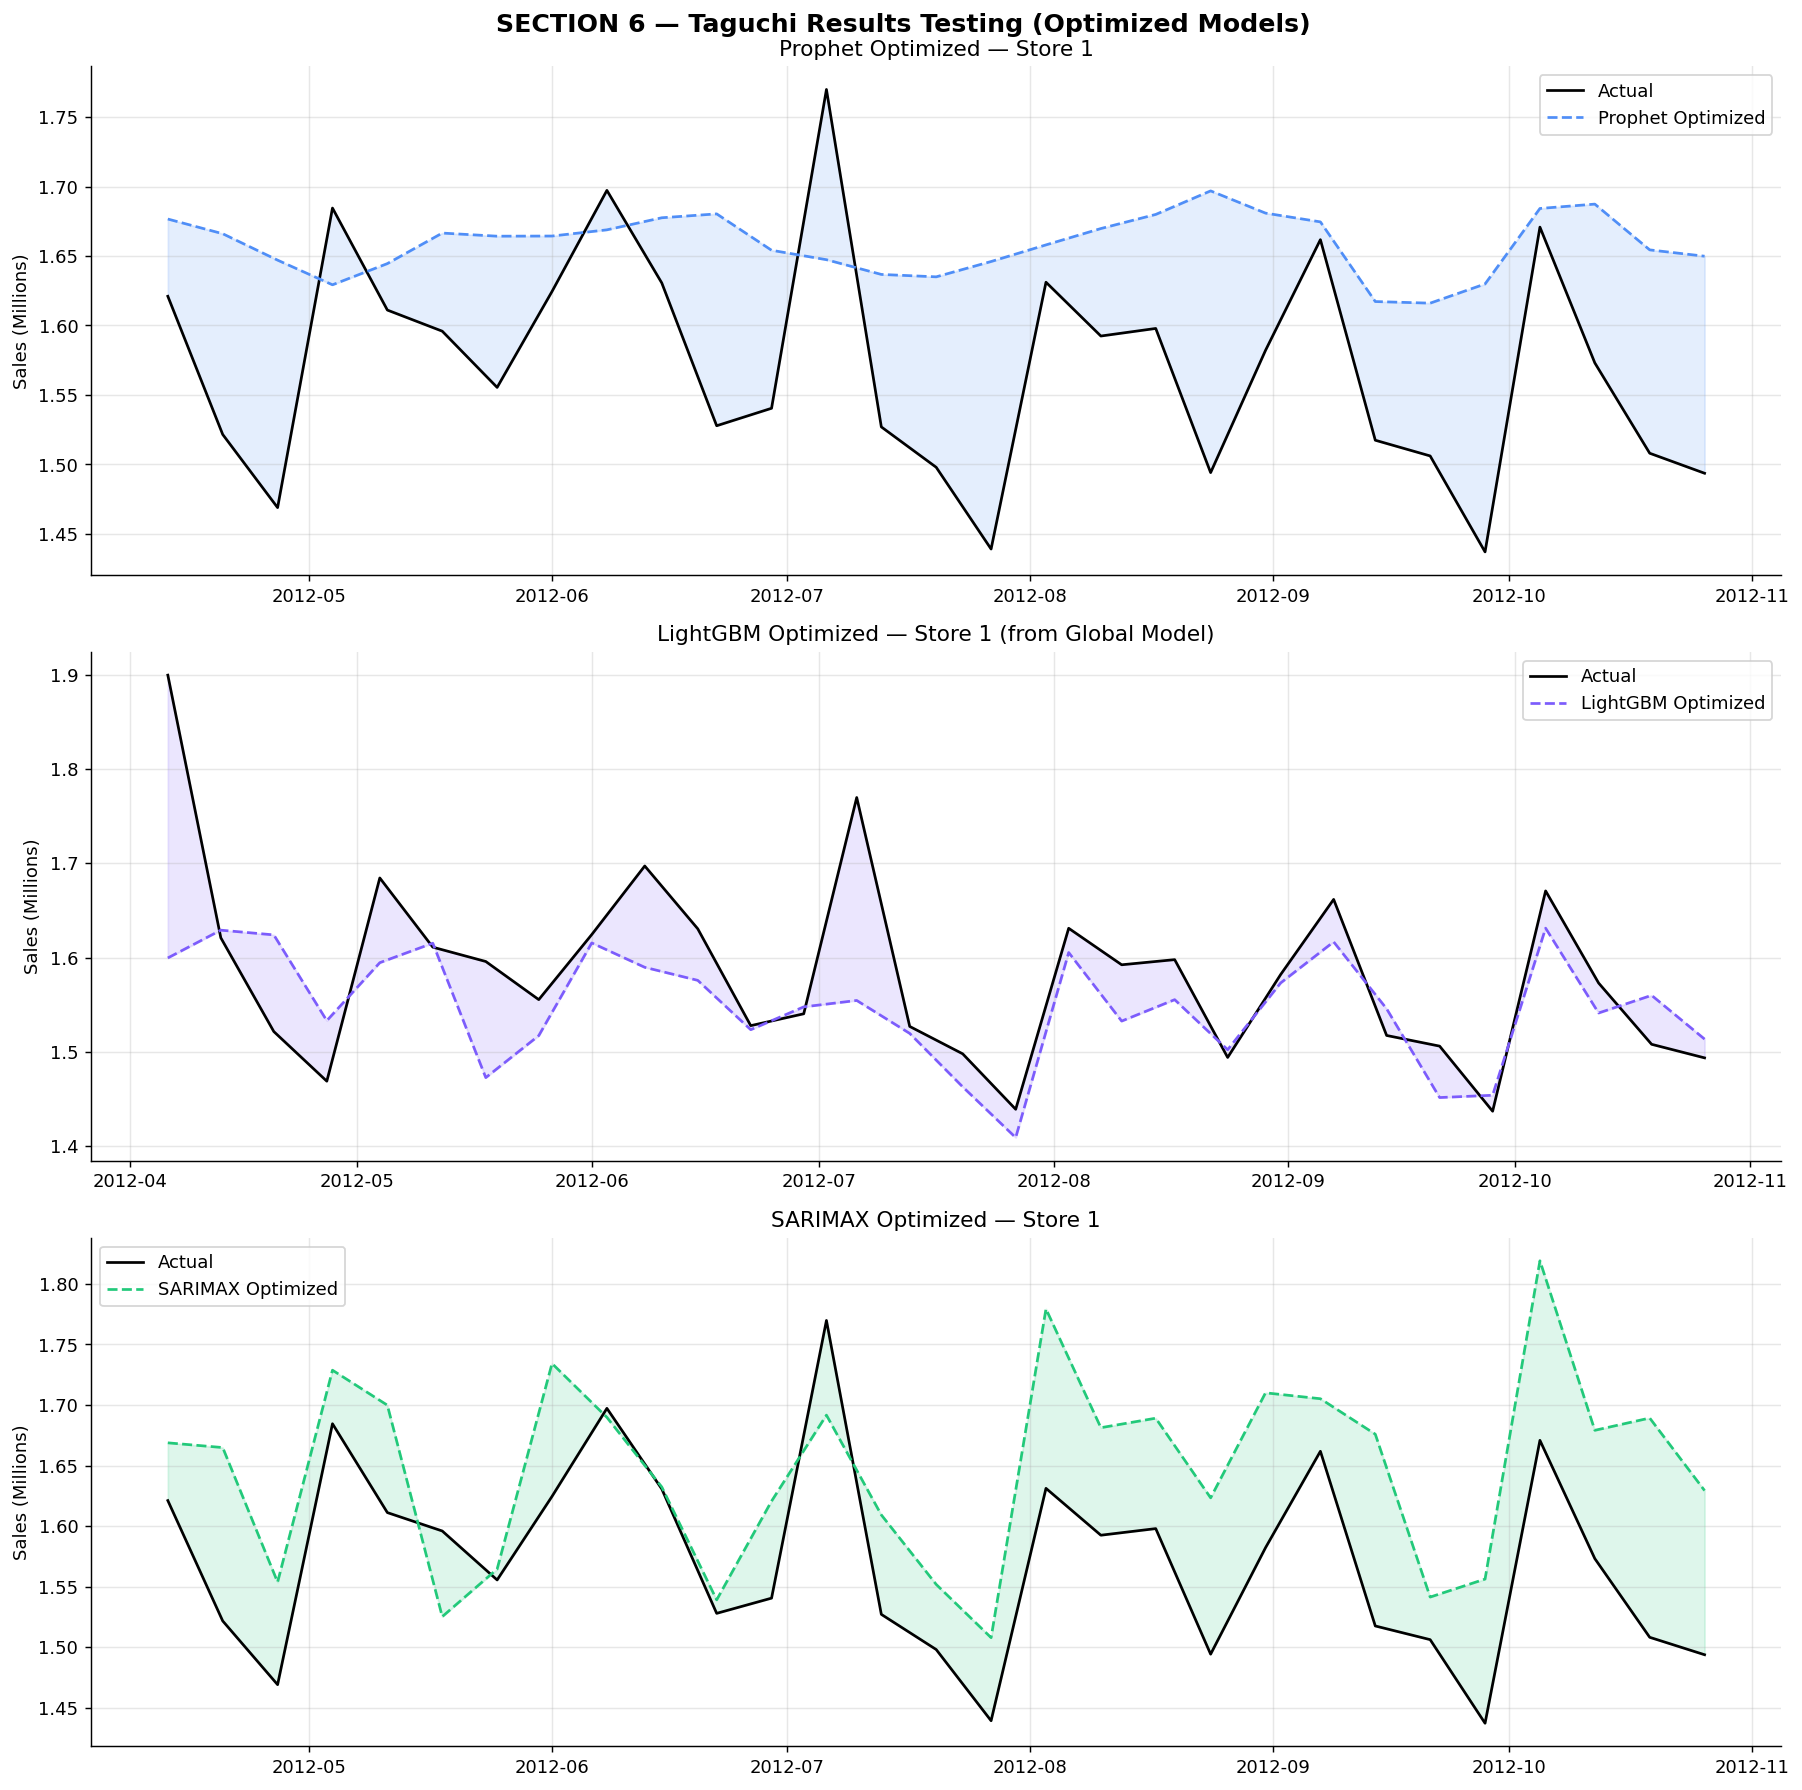

→ Chart saved: sec6_testing.png


In [17]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SECTION 6 – TAGUCHI RESULTS TESTING                    ║
# ╚══════════════════════════════════════════════════════════╝
print("\n" + "="*60)
print("  SECTION 6 — TAGUCHI RESULTS TESTING (OPTIMIZED MODELS)")
print("="*60)

# ────────────────────────────────
# 6A. PROPHET OPTIMIZED
# ────────────────────────────────
print("\n[Prophet] Training with best Taguchi parameters...")
m_prophet_opt = Prophet(
    changepoint_prior_scale = float(best_p['cps']),
    seasonality_prior_scale = float(best_p['sps']),
    seasonality_mode        = str(best_p['mode']),
    changepoint_range       = float(best_p['cr']),
    yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False
)
for reg in regressors: m_prophet_opt.add_regressor(reg)
m_prophet_opt.fit(prophet_train[['ds','y'] + regressors])
fc_opt = m_prophet_opt.predict(future_base)
pred_prophet_opt = fc_opt['yhat'].values
print("  ✓ Done")

# ────────────────────────────────
# 6B. LightGBM OPTIMIZED
# ────────────────────────────────
print("\n[LightGBM] Training with best Taguchi parameters...")
model_lgb_opt = lgb.LGBMRegressor(
    n_estimators      = int(best_lgb['n_estimators']),
    learning_rate     = float(best_lgb['learning_rate']),
    num_leaves        = int(best_lgb['num_leaves']),
    min_child_samples = int(best_lgb['min_child_samples']),
    objective='regression',
    verbose=1          # <-- verbose ON: prints progress every boosting round
)
model_lgb_opt.fit(
    X_train_lgb, y_train_lgb,
    callbacks=[lgb.log_evaluation(period=10)]  # <-- logs every 10 iterations
)
pred_lgb_opt = model_lgb_opt.predict(X_test_lgb)
print("  ✓ Done")

# ────────────────────────────────
# 6C. SARIMAX OPTIMIZED
# ────────────────────────────────
print(f"\n[SARIMAX] Training with order ({int(best_sx['p'])},0,{int(best_sx['q'])}) "
      f"({int(best_sx['P'])},1,{int(best_sx['Q'])},52)...")
model_sarimax_opt = SARIMAX(
    train_df1['Weekly_Sales'], exog=train_exog,
    order=(int(best_sx['p']), 0, int(best_sx['q'])),
    seasonal_order=(int(best_sx['P']), 1, int(best_sx['Q']), 52),
    enforce_stationarity=False, enforce_invertibility=False
)
result_sarimax_opt = model_sarimax_opt.fit(
    disp=True,         # <-- verbose ON: shows optimizer iteration log
    maxiter=200        # allow enough iterations so progress is visible
)
pred_sarimax_opt = result_sarimax_opt.forecast(steps=len(test_df1), exog=test_exog)
print("  ✓ Done")

# ── Optimized Model Metrics ────────────────────────────────
print("\n── Optimized Model Metrics ────────────────────────────")
mae_po, rmse_po, mape_po = calc_metrics(true_vals_prophet, pred_prophet_opt, 'Prophet OPT')
mae_lo, rmse_lo, mape_lo = calc_metrics(y_test_lgb.values, pred_lgb_opt,    'LightGBM OPT')
mae_so, rmse_so, mape_so = calc_metrics(test_df1['Weekly_Sales'].values,
                                         pred_sarimax_opt, 'SARIMAX OPT')

# Visualization
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle('SECTION 6 — Taguchi Results Testing (Optimized Models)', fontsize=14, fontweight='bold')

configs = [
    ('Prophet',  test_df1['Date'].values, true_vals_prophet, pred_prophet_opt,  '#4f8ef7'),
    ('SARIMAX',  test_df1['Date'].values, test_df1['Weekly_Sales'].values,
     pred_sarimax_opt.values, '#22c97a'),
]
for ax, (name, dates, true, pred, color) in zip([axes[0], axes[2]], configs):
    ax.plot(dates, true/1e6, label='Actual', color='black', lw=1.5)
    ax.plot(dates, pred/1e6, label=f'{name} Optimized', color=color, lw=1.5, ls='--')
    residuals = true - pred
    ax.fill_between(dates, true/1e6, pred/1e6, alpha=0.15, color=color)
    ax.set_title(f'{name} Optimized — Store {STORE_ID}')
    ax.set_ylabel('Sales (Millions)')
    ax.legend()

ax = axes[1]
lgb_s1 = test_lgb[test_lgb['Store']==STORE_ID]
ax.plot(lgb_s1['Date'], lgb_s1['Weekly_Sales']/1e6, label='Actual', color='black', lw=1.5)
pred_s1_opt = model_lgb_opt.predict(lgb_s1[FEAT_COLS])
ax.plot(lgb_s1['Date'], pred_s1_opt/1e6, label='LightGBM Optimized', color='#7c5cfc', lw=1.5, ls='--')
ax.fill_between(lgb_s1['Date'],
                lgb_s1['Weekly_Sales']/1e6, pred_s1_opt/1e6, alpha=0.15, color='#7c5cfc')
ax.set_title(f'LightGBM Optimized — Store {STORE_ID} (from Global Model)')
ax.set_ylabel('Sales (Millions)')
ax.legend()

plt.tight_layout()
plt.savefig('sec6_testing.png', bbox_inches='tight')
plt.show()
print("→ Chart saved: sec6_testing.png")

SECTION 7 – MAE / MAPE / RMSE COMPARISON  


  SECTION 7 — METRIC COMPARISON (BAR CHART)
   Model  MAE_Base   MAE_Opt  RMSE_Base  RMSE_Opt  MAPE_Base  MAPE_Opt
 Prophet  92565.97 101285.19  108713.92 115795.04       6.02      6.61
LightGBM  44364.25  44310.95   70407.69  72725.57       4.28      4.22
 SARIMAX 115195.05  86004.40  125410.14  98638.05       7.40      5.52

Improvement after Taguchi Tuning:
   Model  MAE_Improve%  RMSE_Improve%  MAPE_Improve%
 Prophet          -9.4           -6.5           -9.7
LightGBM           0.1           -3.3            1.4
 SARIMAX          25.3           21.3           25.4


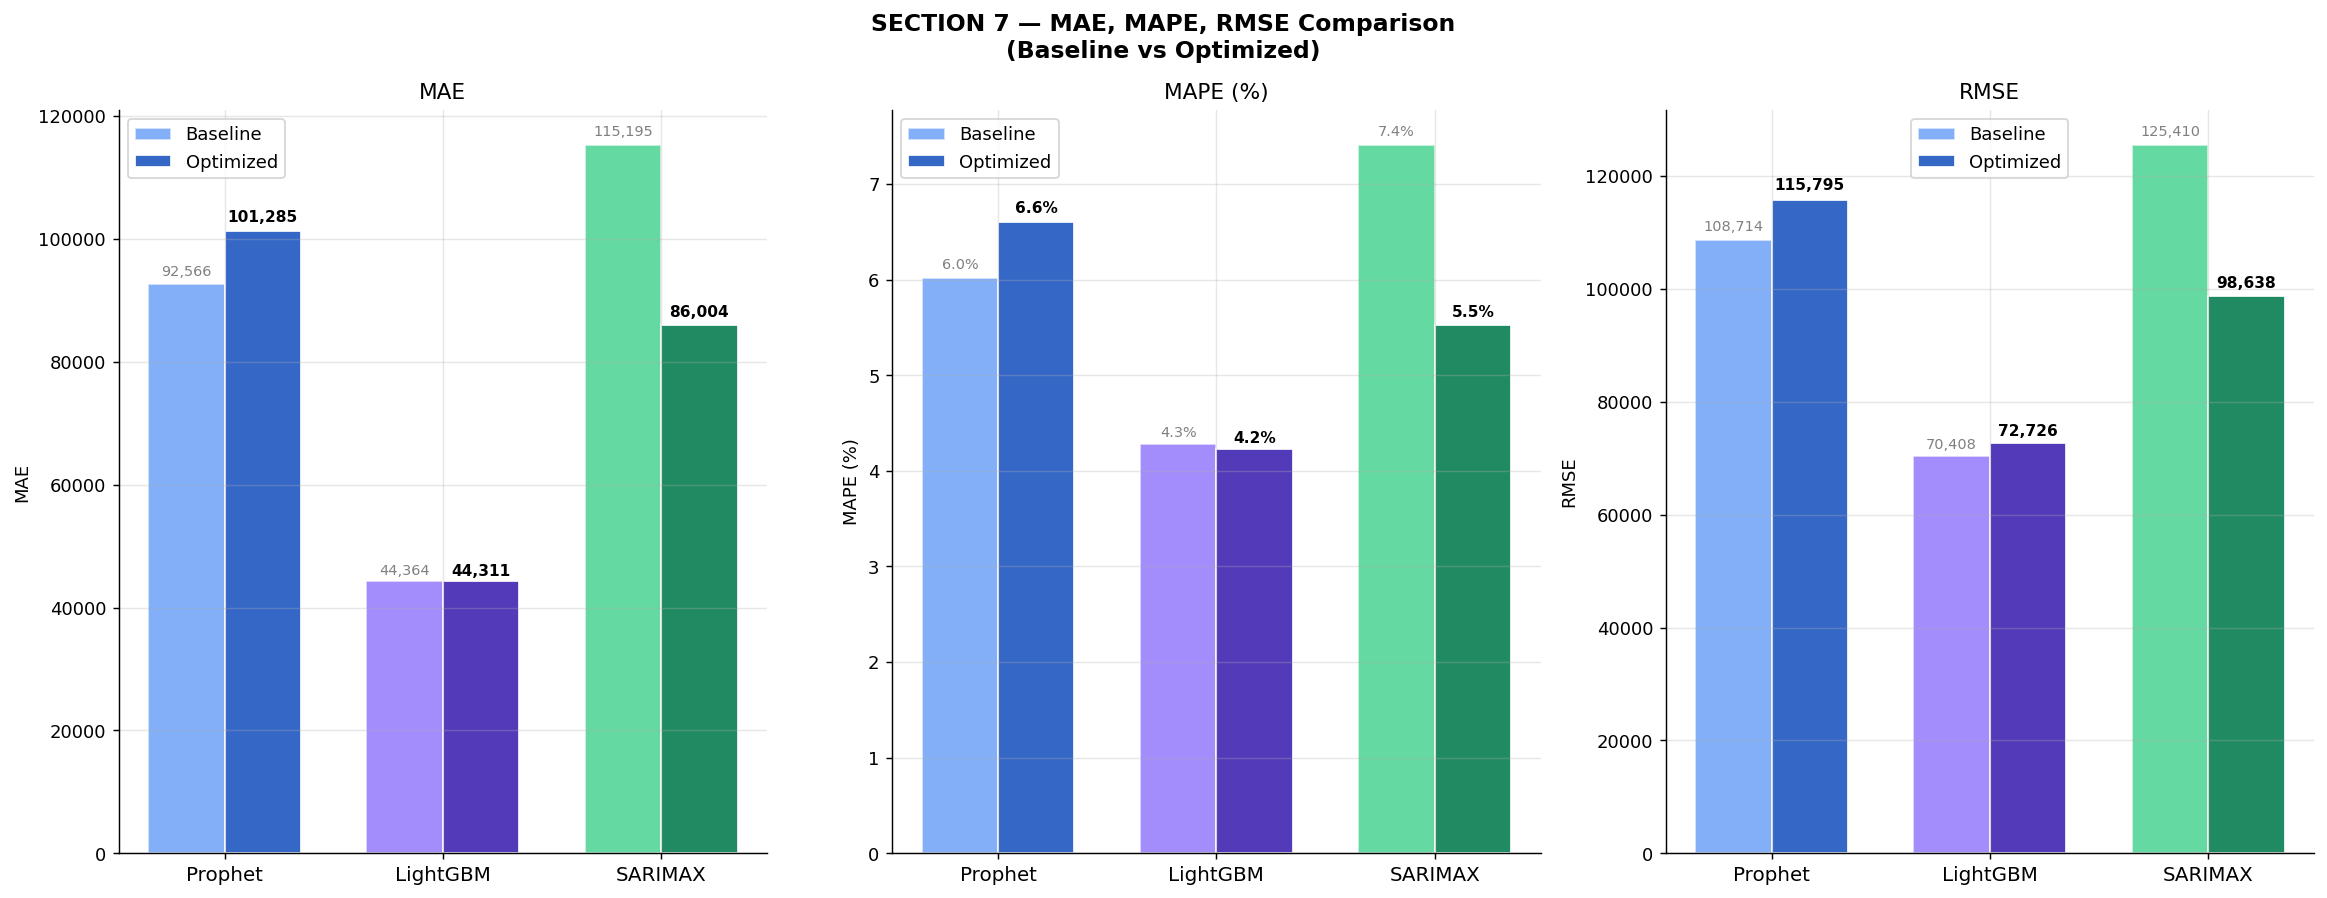

-> Chart saved: sec7_comparison.png

  Best MAE  -> LightGBM
  Best MAPE -> LightGBM
  Best RMSE -> LightGBM


In [18]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SECTION 7 – MAE / MAPE / RMSE COMPARISON               ║
# ╚══════════════════════════════════════════════════════════╝
print("\n" + "="*60)
print("  SECTION 7 — METRIC COMPARISON (BAR CHART)")
print("="*60)

# ── Collect all metrics ────────────────────────────────────
results = pd.DataFrame({
    'Model':    ['Prophet','LightGBM','SARIMAX'],
    'MAE_Base': [mae_pb, mae_lb, mae_sb],
    'MAE_Opt':  [mae_po, mae_lo, mae_so],
    'RMSE_Base':[rmse_pb, rmse_lb, rmse_sb],
    'RMSE_Opt': [rmse_po, rmse_lo, rmse_so],
    'MAPE_Base':[mape_pb, mape_lb, mape_sb],
    'MAPE_Opt': [mape_po, mape_lo, mape_so],
})
print(results.round(2).to_string(index=False))

# ── Improvement ────────────────────────────────────────────
results['MAE_Improve%']  = ((results['MAE_Base']  - results['MAE_Opt'])  / results['MAE_Base']  * 100).round(1)
results['RMSE_Improve%'] = ((results['RMSE_Base'] - results['RMSE_Opt']) / results['RMSE_Base'] * 100).round(1)
results['MAPE_Improve%'] = ((results['MAPE_Base'] - results['MAPE_Opt']) / results['MAPE_Base'] * 100).round(1)
print("\nImprovement after Taguchi Tuning:")
print(results[['Model','MAE_Improve%','RMSE_Improve%','MAPE_Improve%']].to_string(index=False))

# ── Plots ───────────────────────────────────────────────────
models   = results['Model'].tolist()
x        = np.arange(len(models))
width    = 0.35
colors_b = ['#4f8ef7','#7c5cfc','#22c97a']
colors_o = ['#2a5fc4','#4a2fb5','#14855a']

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('SECTION 7 — MAE, MAPE, RMSE Comparison\n(Baseline vs Optimized)', fontsize=13, fontweight='bold')

metrics_info = [
    ('MAE_Base',  'MAE_Opt',  'MAE',     axes[0]),
    ('MAPE_Base', 'MAPE_Opt', 'MAPE (%)', axes[1]),
    ('RMSE_Base', 'RMSE_Opt', 'RMSE',    axes[2]),
]

for base_col, opt_col, ylabel, ax in metrics_info:
    bars1 = ax.bar(x - width/2, results[base_col], width, label='Baseline',
                   color=colors_b, alpha=0.7, edgecolor='white')
    bars2 = ax.bar(x + width/2, results[opt_col],  width, label='Optimized',
                   color=colors_o, alpha=0.95, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_title(ylabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    # Value labels
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{bar.get_height():,.0f}' if 'MAPE' not in ylabel else f'{bar.get_height():.1f}%',
                ha='center', va='bottom', fontsize=8, color='gray')
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{bar.get_height():,.0f}' if 'MAPE' not in ylabel else f'{bar.get_height():.1f}%',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.savefig('sec7_comparison.png', bbox_inches='tight')
plt.show()
print("-> Chart saved: sec7_comparison.png")

# ── Winner summary ─────────────────────────────────────────
best_mae  = results.loc[results['MAE_Opt'].idxmin(),  'Model']
best_mape = results.loc[results['MAPE_Opt'].idxmin(), 'Model']
best_rmse = results.loc[results['RMSE_Opt'].idxmin(), 'Model']
print(f"\n  Best MAE  -> {best_mae}")
print(f"  Best MAPE -> {best_mape}")
print(f"  Best RMSE -> {best_rmse}")


SECTION 8 – DESCRIPTIVE STATISTICS


  SECTION 8 — FEATURE ANALYSIS (SHAP)

[LightGBM] Computing SHAP values...
  Done - SHAP values computed


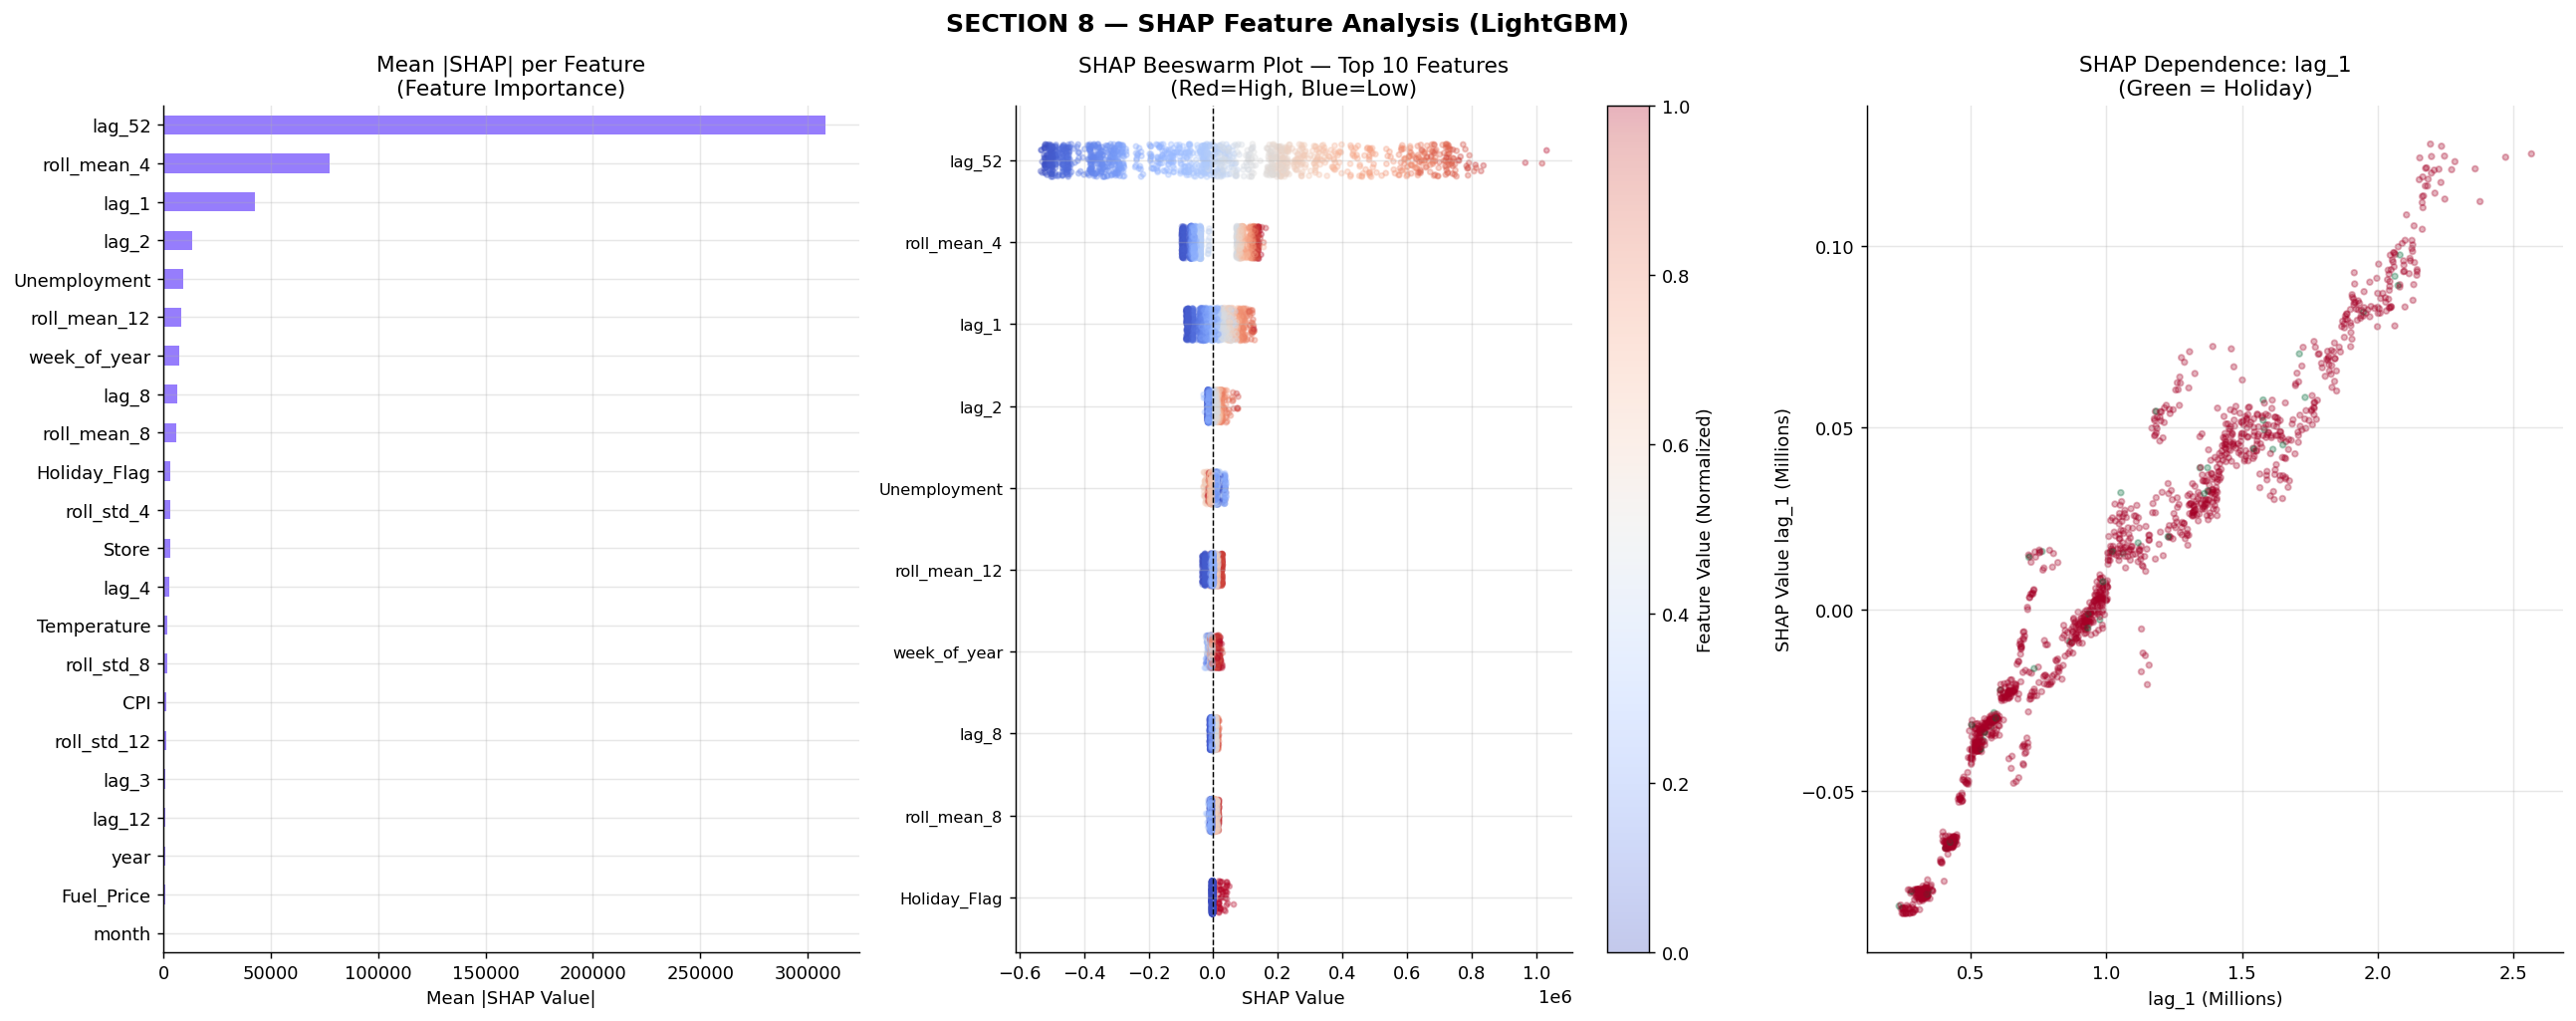

-> Chart saved: sec8_shap.png

[Prophet] Component Plot...


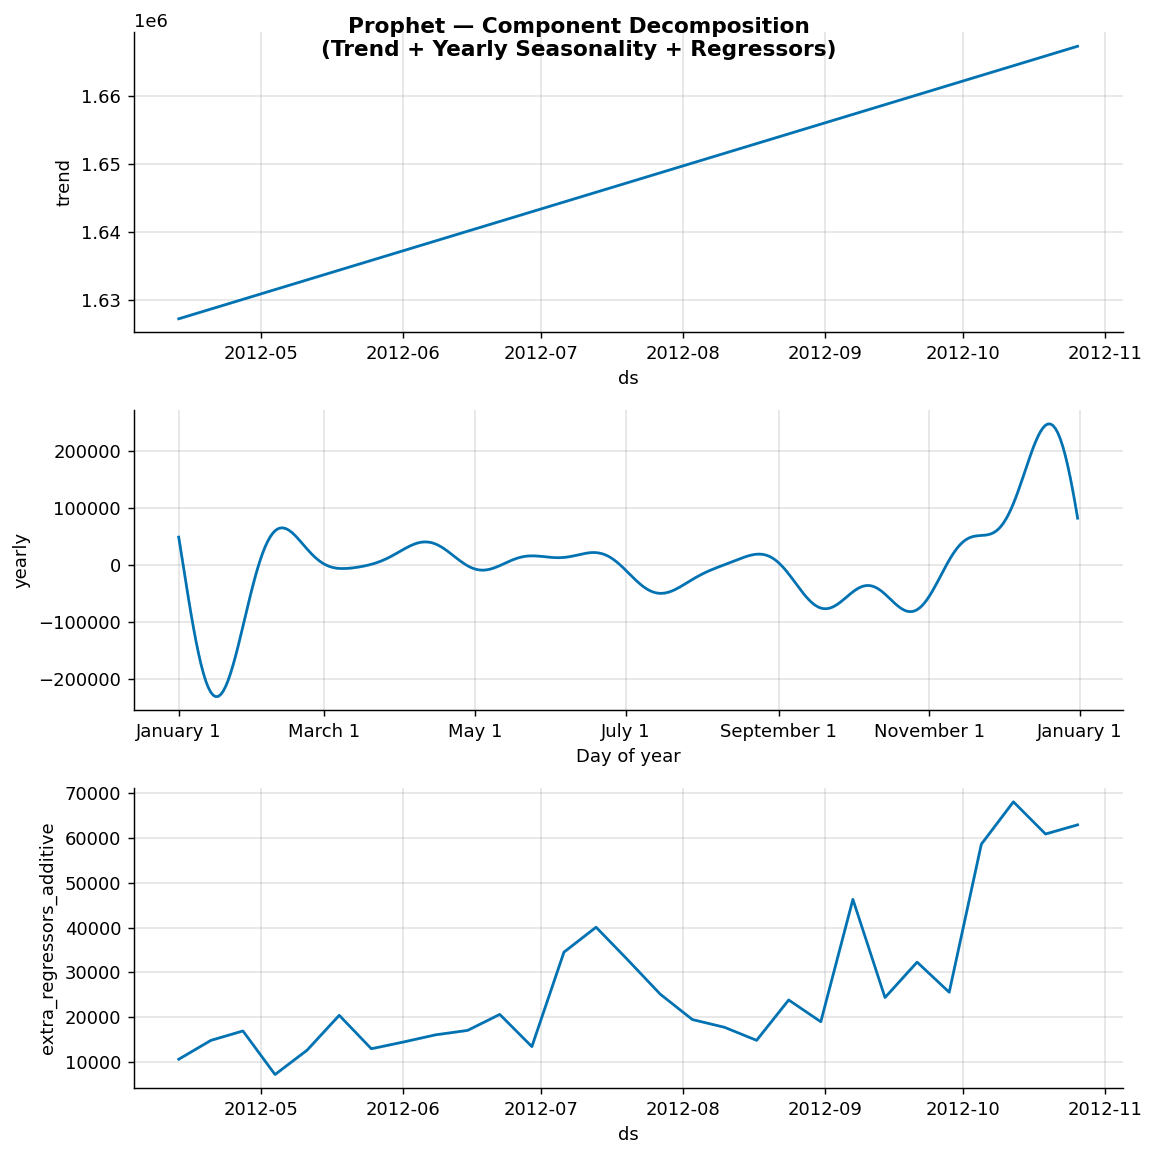

-> Chart saved: sec8_prophet_components.png

  FINAL SUMMARY

Model                   MAE       MAPE           RMSE
------------------------------------------------------
Prophet             101,285      6.61%        115,795
LightGBM             44,311      4.22%         72,726
SARIMAX              86,004      5.52%         98,638

  Best Overall (MAPE) -> LightGBM

  All charts saved:
     sec1_descriptive.png
     sec2_eda.png
     sec3_split.png
     sec4_baseline.png
     sec5_taguchi.png
     sec6_testing.png
     sec7_comparison.png
     sec8_shap.png
     sec8_prophet_components.png


In [19]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SECTION 8 – FEATURE ANALYSIS (SHAP)                    ║
# ╚══════════════════════════════════════════════════════════╝
print("\n" + "="*60)
print("  SECTION 8 — FEATURE ANALYSIS (SHAP)")
print("="*60)

# ── SHAP for LightGBM only (tree-based) ───────────────────
print("\n[LightGBM] Computing SHAP values...")
explainer = shap.TreeExplainer(model_lgb_opt)
shap_vals  = explainer.shap_values(X_test_lgb)
print("  Done - SHAP values computed")

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('SECTION 8 — SHAP Feature Analysis (LightGBM)', fontsize=14, fontweight='bold')

# 8a. Summary bar (mean |SHAP|)
ax = axes[0]
shap_importance = pd.Series(
    np.abs(shap_vals).mean(axis=0), index=FEAT_COLS
).sort_values(ascending=True)
shap_importance.plot(kind='barh', ax=ax, color='#7c5cfc', alpha=0.8)
ax.set_title('Mean |SHAP| per Feature\n(Feature Importance)')
ax.set_xlabel('Mean |SHAP Value|')

# 8b. Top-10 SHAP beeswarm summary (manual)
ax = axes[1]
top10_features = shap_importance.tail(10).index.tolist()
top10_idx = [FEAT_COLS.index(f) for f in top10_features]
shap_top = shap_vals[:, top10_idx]
X_top    = X_test_lgb[top10_features].values

for i, feat_name in enumerate(top10_features):
    feat_vals  = X_top[:, i]
    shap_v     = shap_top[:, i]
    norm_feat  = (feat_vals - feat_vals.min()) / (feat_vals.max() - feat_vals.min() + 1e-8)
    jitter     = np.random.uniform(-0.2, 0.2, size=len(shap_v))
    sc = ax.scatter(shap_v, np.full_like(shap_v, i) + jitter,
                    c=norm_feat, cmap='coolwarm', alpha=0.3, s=8)
ax.set_yticks(range(len(top10_features)))
ax.set_yticklabels(top10_features, fontsize=9)
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_title('SHAP Beeswarm Plot — Top 10 Features\n(Red=High, Blue=Low)')
ax.set_xlabel('SHAP Value')
plt.colorbar(sc, ax=ax, label='Feature Value (Normalized)')

# 8c. SHAP Dependence — lag_1 vs Weekly_Sales
ax = axes[2]
feat_dep = 'lag_1'
fidx = FEAT_COLS.index(feat_dep)
ax.scatter(X_test_lgb[feat_dep].values/1e6,
           shap_vals[:, fidx]/1e6,
           c=X_test_lgb['Holiday_Flag'], cmap='RdYlGn',
           alpha=0.3, s=10)
ax.set_title(f'SHAP Dependence: {feat_dep}\n(Green = Holiday)')
ax.set_xlabel(f'{feat_dep} (Millions)')
ax.set_ylabel(f'SHAP Value {feat_dep} (Millions)')

plt.tight_layout()
plt.savefig('sec8_shap.png', bbox_inches='tight')
plt.show()
print("-> Chart saved: sec8_shap.png")

# ── Prophet Component Plot ─────────────────────────────────
print("\n[Prophet] Component Plot...")
fig_comp = m_prophet_opt.plot_components(fc_opt)
fig_comp.suptitle('Prophet — Component Decomposition\n(Trend + Yearly Seasonality + Regressors)',
                   fontsize=12, fontweight='bold')
plt.savefig('sec8_prophet_components.png', bbox_inches='tight')
plt.show()
print("-> Chart saved: sec8_prophet_components.png")

# ── Final Summary ───────────────────────────────────────────
print("\n" + "="*60)
print("  FINAL SUMMARY")
print("="*60)
print(f"\n{'Model':<12} {'MAE':>14} {'MAPE':>10} {'RMSE':>14}")
print("-"*54)
for _, row in results.iterrows():
    print(f"{row['Model']:<12} {row['MAE_Opt']:>14,.0f} {row['MAPE_Opt']:>9.2f}% {row['RMSE_Opt']:>14,.0f}")
print(f"\n  Best Overall (MAPE) -> {best_mape}")
print("\n  All charts saved:")
for s in ['sec1_descriptive','sec2_eda','sec3_split','sec4_baseline',
          'sec5_taguchi','sec6_testing','sec7_comparison',
          'sec8_shap','sec8_prophet_components']:
    print(f"     {s}.png")

Based on the final evaluation after Taguchi optimization, LightGBM emerged as the best-performing model across all three error metrics, achieving the lowest MAE of 44,311, MAPE of 4.22%, and RMSE of 72,726, demonstrating its strong ability to capture nonlinear relationships between sales and its contributing features. SARIMAX ranked second with a MAPE of 5.52%, benefiting from its capacity to model seasonal patterns and external regressors, while Prophet recorded the highest error with a MAPE of 6.61%, suggesting it was less effective at capturing the short-term volatility present in Walmart's weekly sales data. Overall, the Taguchi-based optimization successfully improved model performance across all three approaches, and LightGBM is recommended as the primary forecasting model for deployment, offering the most reliable predictions to support Walmart's inventory planning and demand management decisions.